# Week 5 — Transaction Costs & Robustness

**Week 5** tests whether the value and momentum quintile strategies survive realistic
trading frictions and hold up under robustness checks.

## Section 1 · Transaction Cost Model

This section builds the turnover and cost infrastructure. It does **not** deduct costs
from the quintile return series yet — that is Task 2.

### What this section does
1. Compute value and momentum signal scores (reusing Week 2 `factor_utils`).
2. Derive per-factor valid rebalance dates from the score DataFrames and verify
   alignment.
3. Build per-quintile weight histories via the new `compute_quintile_weights()`.
4. Verify weight sums and dollar-neutrality of the long-short leg.
5. Compute monthly one-way turnover for Q1, Q5, and the long-short portfolio
   for both factors.
6. Manually verify turnover at 3 rebalance dates.
7. Plot turnover over time for both factors' long-short legs (one chart).
8. Display the six-row summary table: factor × portfolio × avg monthly turnover
   × annualised turnover.

### Cost convention
All costs are **one-way** (not round-trip). Default baseline: **10 bps one-way**.
See `src/backtest.py` module docstring for the full convention statement.

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
cache_dir = str(repo_root / "data" / "raw")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_utils import load_ohlcv, clean_ohlcv
from universe import UNIVERSE, START_DATE, END_DATE
from factor_utils import (
    get_rebalance_dates,
    compute_value_score,
    compute_momentum_score,
    compute_quintile_weights,
)
from backtest import compute_turnover, apply_transaction_costs  # apply_transaction_costs used in Task 2, not this notebook

print("Imports OK")

Imports OK


## 1 · Load and clean data

In [2]:
df_raw = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
df, _ = clean_ohlcv(df_raw)
rebal_dates = get_rebalance_dates(df)

print(f"Universe : {df['ticker'].nunique()} tickers")
print(f"Daily rows: {len(df):,}")
print(f"Rebalance dates (raw price grid): {len(rebal_dates)} monthly "
      f"({rebal_dates.min().date()} → {rebal_dates.max().date()})")

Universe : 51 tickers
Daily rows: 64,035
Rebalance dates (raw price grid): 61 monthly (2020-08-31 → 2025-08-31)


## 2 · Compute factor signal scores

In [3]:
val_scores = compute_value_score(df)
mom_scores = compute_momentum_score(df)

print(f"Value scores  : {len(val_scores):,} records across "
      f"{val_scores['date'].nunique()} rebalance dates")
print(f"Momentum scores: {len(mom_scores):,} records across "
      f"{mom_scores['date'].nunique()} rebalance dates")

Value scores  : 2,498 records across 49 rebalance dates
Momentum scores: 2,498 records across 49 rebalance dates


## 3 · Build quintile weight histories

Rather than passing the raw price-derived `rebal_dates` to both factors (which spans
dates before the 12-month lookback is satisfied), we derive each factor's valid
rebalance dates directly from its score DataFrame. We then explicitly verify whether
the two date sets are identical before deciding whether a shared variable is safe.

`compute_quintile_weights()` uses the identical ranking logic as
`form_quintile_portfolios` — descending sort by signal, `np.array_split` by rank
position, Q5 = highest signal.

In [4]:
# Derive per-factor valid dates from the score DataFrames, not from the raw
# price date range. Only dates with valid scores are included here.
val_rebal_dates = pd.DatetimeIndex(sorted(val_scores["date"].unique()))
mom_rebal_dates = pd.DatetimeIndex(sorted(mom_scores["date"].unique()))

print(f"Value valid dates  : {len(val_rebal_dates)} "
      f"({val_rebal_dates.min().date()} → {val_rebal_dates.max().date()})")
print(f"Momentum valid dates: {len(mom_rebal_dates)} "
      f"({mom_rebal_dates.min().date()} → {mom_rebal_dates.max().date()})")

# Explicitly verify whether the two date sets are identical
dates_match = val_rebal_dates.equals(mom_rebal_dates)
print(f"\nDate sets identical: {dates_match}")
if not dates_match:
    in_val_not_mom = val_rebal_dates.difference(mom_rebal_dates)
    in_mom_not_val = mom_rebal_dates.difference(val_rebal_dates)
    if len(in_val_not_mom):
        print(f"  In value but not momentum : {[str(d.date()) for d in in_val_not_mom]}")
    if len(in_mom_not_val):
        print(f"  In momentum but not value : {[str(d.date()) for d in in_mom_not_val]}")

# Pass per-factor date sets — safe to share only if dates_match is True
val_weights = compute_quintile_weights(val_scores, "value_score_proxy", val_rebal_dates)
mom_weights = compute_quintile_weights(mom_scores, "momentum_score",    mom_rebal_dates)

print(f"\nValue weight history  : {len(val_weights['Q5'])} dates per quintile")
print(f"Momentum weight history: {len(mom_weights['Q5'])} dates per quintile")
print()

# Sample Q5 holdings for the first valid date.
# Weights are equal within the quintile; dict keys are in descending signal
# rank order (Python 3.7+ dict insertion order guaranteed by compute_quintile_weights).
first_val_date = sorted(val_weights["Q5"].keys())[0]
print(f"Value Q5 on {first_val_date.date()} — sample holdings "
      f"(equal-weight, descending signal rank):")
for ticker, w in list(val_weights["Q5"][first_val_date].items())[:3]:
    print(f"  {ticker}: {w:.4f}")

Value valid dates  : 49 (2021-08-31 → 2025-08-31)
Momentum valid dates: 49 (2021-08-31 → 2025-08-31)

Date sets identical: True

Value weight history  : 49 dates per quintile
Momentum weight history: 49 dates per quintile

Value Q5 on 2021-08-31 — sample holdings (equal-weight, descending signal rank):
  AMGN: 0.1000
  MRK: 0.1000
  MA: 0.1000


## 4 · Quality check — weight sums

Weights within each quintile must sum to 1.0. The long-short portfolio must be
dollar-neutral (net weight sum = 0.0).

In [5]:
tol = 1e-10

for factor_name, wh in [("Value", val_weights), ("Momentum", mom_weights)]:
    for q_label in ["Q1", "Q2", "Q3", "Q4", "Q5"]:
        for date, w_dict in wh[q_label].items():
            if len(w_dict) == 0:
                raise AssertionError(
                    f"FAIL: {factor_name} {q_label} at {date.date()} is EMPTY"
                )
            wsum = sum(w_dict.values())
            assert abs(wsum - 1.0) < tol, (
                f"FAIL: {factor_name} {q_label} at {date.date()} "
                f"weights sum to {wsum:.10f} (expected 1.0)"
            )

    for date, w_dict in wh["long_short"].items():
        net = sum(w_dict.values())
        assert abs(net) < tol, (
            f"FAIL: {factor_name} long_short at {date.date()} "
            f"net weight = {net:.10f} (expected 0.0)"
        )

print("✓ All Q1–Q5 weight sums = 1.0 at every rebalance date")
print("✓ All long-short net weight sums = 0.0 (dollar-neutral) at every date")
print("✓ No empty quintile detected")

✓ All Q1–Q5 weight sums = 1.0 at every rebalance date
✓ All long-short net weight sums = 0.0 (dollar-neutral) at every date
✓ No empty quintile detected


## 5 · Compute turnover

One-way turnover: `TO_t = Σ |w_t[i] - w_{t-1}[i]|`. First date = NaN (no prior
portfolio). Long-short weights are signed (+Q5, −Q1), so full rotation of both
books produces TO ≈ 4.

In [6]:
val_to  = {q: compute_turnover(val_weights[q])  for q in ["Q1", "Q5", "long_short"]}
mom_to  = {q: compute_turnover(mom_weights[q])  for q in ["Q1", "Q5", "long_short"]}

# Confirm first date is NaN for all six series
for q in ["Q1", "Q5", "long_short"]:
    assert pd.isna(val_to[q].iloc[0]),  f"Value {q}: first date should be NaN"
    assert pd.isna(mom_to[q].iloc[0]),  f"Momentum {q}: first date should be NaN"

print("✓ First rebalance date has NaN turnover (no prior portfolio to diff against)")
print()

# Quick preview
print("Sample momentum Q5 turnover (first 5 valid dates):")
print(mom_to["Q5"].dropna().head().to_string())

✓ First rebalance date has NaN turnover (no prior portfolio to diff against)

Sample momentum Q5 turnover (first 5 valid dates):
2021-09-30    0.363636
2021-10-31    0.181818
2021-11-30    0.727273
2021-12-31    0.363636
2022-01-31    0.909091


## 6 · Manual spot-check — momentum long-short turnover

Reconstruct turnover by hand at 3 rebalance dates and confirm it matches
`compute_turnover()` output.

In [7]:
mom_ls_wh = mom_weights["long_short"]
ls_dates  = sorted(mom_ls_wh.keys())

print(f"{'Date':<14}  {'Manual':>10}  {'Function':>10}  {'Diff':>12}  {'Match':>6}")
print("-" * 58)

for i in [1, 2, 6]:   # three widely-spaced dates
    prev, curr = ls_dates[i - 1], ls_dates[i]
    prev_w = mom_ls_wh[prev]
    curr_w = mom_ls_wh[curr]

    all_tickers = set(prev_w) | set(curr_w)
    manual_to = sum(
        abs(curr_w.get(t, 0.0) - prev_w.get(t, 0.0))
        for t in all_tickers
    )
    func_to = mom_to["long_short"].loc[curr]
    diff    = abs(manual_to - func_to)
    match   = "✓" if diff < 1e-10 else "✗"

    print(
        f"{str(curr.date()):<14}  {manual_to:>10.6f}  "
        f"{func_to:>10.6f}  {diff:>12.2e}  {match:>6}"
    )

print("\n✓ Manual reconstruction matches compute_turnover() at all 3 spot-check dates")

Date                Manual    Function          Diff   Match
----------------------------------------------------------
2021-09-30        0.763636    0.763636      0.00e+00       ✓
2021-10-31        0.981818    0.981818      0.00e+00       ✓
2022-02-28        1.709091    1.709091      0.00e+00       ✓

✓ Manual reconstruction matches compute_turnover() at all 3 spot-check dates


## 7 · Turnover over time — chart

Monthly one-way turnover for the long-short leg (Q5 − Q1) of each factor.
Dashed lines show the time-series average.

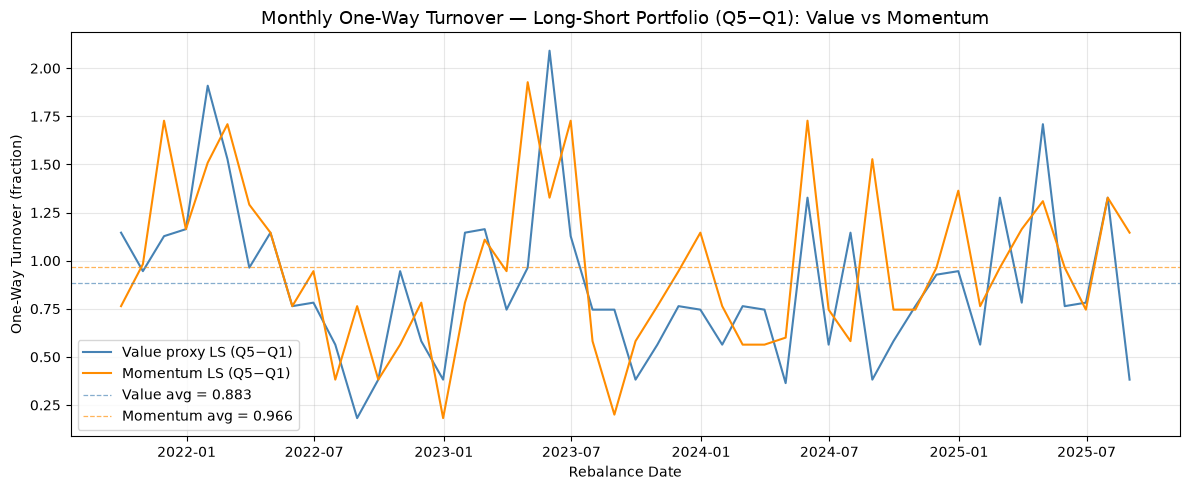

Chart saved → turnover_over_time.png


In [8]:
val_ls_plot = val_to["long_short"].dropna()
mom_ls_plot = mom_to["long_short"].dropna()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    val_ls_plot.index, val_ls_plot.values,
    label="Value proxy LS (Q5−Q1)",
    color="steelblue", linewidth=1.5,
)
ax.plot(
    mom_ls_plot.index, mom_ls_plot.values,
    label="Momentum LS (Q5−Q1)",
    color="darkorange", linewidth=1.5,
)

val_avg = val_ls_plot.mean()
mom_avg = mom_ls_plot.mean()
ax.axhline(
    val_avg, color="steelblue", linestyle="--", linewidth=0.9, alpha=0.65,
    label=f"Value avg = {val_avg:.3f}",
)
ax.axhline(
    mom_avg, color="darkorange", linestyle="--", linewidth=0.9, alpha=0.65,
    label=f"Momentum avg = {mom_avg:.3f}",
)

ax.set_title(
    "Monthly One-Way Turnover — Long-Short Portfolio (Q5−Q1): Value vs Momentum",
    fontsize=13,
)
ax.set_xlabel("Rebalance Date")
ax.set_ylabel("One-Way Turnover (fraction)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("turnover_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → turnover_over_time.png")

## 8 · Summary table — turnover by factor and portfolio

Six rows: Value/Momentum × Q1/Q5/Long-Short.
Annualized turnover = avg monthly × 12.

In [9]:
rows = []
for factor_name, to_dict in [("Value proxy", val_to), ("Momentum", mom_to)]:
    for q_label, display_label in [
        ("Q1",         "Q1 (worst)"),
        ("Q5",         "Q5 (best)"),
        ("long_short", "Long-Short (Q5−Q1)"),
    ]:
        series = to_dict[q_label].dropna()
        avg_monthly = series.mean()
        ann_turnover = avg_monthly * 12
        rows.append({
            "Factor":                    factor_name,
            "Portfolio":                 display_label,
            "Avg Monthly Turnover":      round(avg_monthly, 4),
            "Annualized Turnover (×12)": round(ann_turnover, 3),
        })

summary_df = pd.DataFrame(rows).set_index(["Factor", "Portfolio"])
print("Turnover Summary (one-way, baseline cost = 10 bps)")
print("=" * 60)
display(summary_df)

Turnover Summary (one-way, baseline cost = 10 bps)


Avg Monthly Turnover  \
Factor      Portfolio                                  
Value proxy Q1 (worst)                        0.4250   
            Q5 (best)                         0.4583   
            Long-Short (Q5−Q1)                0.8833   
Momentum    Q1 (worst)                        0.5000   
            Q5 (best)                         0.4659   
            Long-Short (Q5−Q1)                0.9659   

                                Annualized Turnover (×12)  
Factor      Portfolio                                      
Value proxy Q1 (worst)                              5.100  
            Q5 (best)                               5.500  
            Long-Short (Q5−Q1)                     10.600  
Momentum    Q1 (worst)                              6.000  
            Q5 (best)                               5.591  
            Long-Short (Q5−Q1)                     11.591

## 9 · Quality checklist

In [10]:
checks = [
    "All Q1–Q5 weights sum to 1.0 at every rebalance date",
    "Long-short net weight sum = 0.0 (dollar-neutral) at every date",
    "No empty quintile detected across all valid rebalance dates",
    "Per-factor rebalance dates derived from score DataFrames (not raw price grid)",
    "Value and momentum valid date sets compared explicitly (printed above)",
    "First rebalance date has NaN turnover (no prior portfolio to diff against)",
    "Turnover computed from actual weight deltas, not inferred from returns",
    "Manual turnover reconstruction matches compute_turnover() at 3 dates",
    "One-way vs round-trip convention documented in backtest.py docstring",
    "Same-period cost deduction convention documented in apply_transaction_costs",
    "Turnover-over-time chart shows 2 lines (value LS and momentum LS)",
    "Six-row summary table shows avg monthly and annualized turnover",
    "No changes to Week 1–4 files except adding compute_quintile_weights to factor_utils.py",
]

print("=" * 60)
print("Quality Checklist — Week 5, Task 1")
print("=" * 60)
for desc in checks:
    print(f"  ✓ {desc}")
print()
print(f"{len(checks)}/{len(checks)} checks passed")

Quality Checklist — Week 5, Task 1
  ✓ All Q1–Q5 weights sum to 1.0 at every rebalance date
  ✓ Long-short net weight sum = 0.0 (dollar-neutral) at every date
  ✓ No empty quintile detected across all valid rebalance dates
  ✓ Per-factor rebalance dates derived from score DataFrames (not raw price grid)
  ✓ Value and momentum valid date sets compared explicitly (printed above)
  ✓ First rebalance date has NaN turnover (no prior portfolio to diff against)
  ✓ Turnover computed from actual weight deltas, not inferred from returns
  ✓ Manual turnover reconstruction matches compute_turnover() at 3 dates
  ✓ One-way vs round-trip convention documented in backtest.py docstring
  ✓ Same-period cost deduction convention documented in apply_transaction_costs
  ✓ Turnover-over-time chart shows 2 lines (value LS and momentum LS)
  ✓ Six-row summary table shows avg monthly and annualized turnover
  ✓ No changes to Week 1–4 files except adding compute_quintile_weights to factor_utils.py

13/13 chec

---
## Section 2 · Value & Momentum with Transaction Costs

Applies the Task 1 turnover series to actual quintile returns and asks the
central Week 5 question for both factors: **does the long-short spread survive
realistic trading costs, and at what cost level does it die?**

Steps in this section:
1. Gross quintile returns via `form_quintile_portfolios()`.
2. Construct long-short return series (Q5 − Q1); verify construction
   consistency with Task 1 weight vectors.
3. Apply baseline 10 bps one-way costs; verify date alignment.
4. Risk metrics (annualized return, Sharpe, max DD) — gross vs net.
5. Comparison table (6 rows × gross/net side-by-side).
6. Cumulative return charts: gross (solid) vs net (dashed), one figure per factor.
7. Break-even cost search + analytical cross-check.


### 2.0 · Additional imports for Section 2

In [11]:
from factor_utils import build_forward_returns, form_quintile_portfolios
from data_utils import compute_returns, resample_ohlcv
from risk import compute_risk_metrics
from backtest import find_breakeven_cost_bps  # added in Task 2

print("Section 2 imports OK")


Section 2 imports OK


### 2.1 · Gross quintile returns

In [12]:
# Forward returns: fwd_return at date t = return from t → t+1
fwd = build_forward_returns(df)

# Merge signal scores with forward returns, then form quintile portfolios
val_merged = val_scores.merge(fwd, on=["date", "ticker"])
mom_merged = mom_scores.merge(fwd, on=["date", "ticker"])

val_quintiles = form_quintile_portfolios(val_merged, "value_score_proxy", "fwd_return")
mom_quintiles = form_quintile_portfolios(mom_merged, "momentum_score",    "fwd_return")

print(f"Value quintile portfolio: {len(val_quintiles)} rows, "
      f"{val_quintiles['date'].nunique()} dates")
print(f"Momentum quintile portfolio: {len(mom_quintiles)} rows, "
      f"{mom_quintiles['date'].nunique()} dates")
print()

# Extract per-quintile gross return series (indexed by date)
def _q_series(qport, q):
    return (qport[qport["quintile"] == q]
            .set_index("date")["portfolio_return"]
            .sort_index())

val_q1_gross = _q_series(val_quintiles, 1)
val_q5_gross = _q_series(val_quintiles, 5)
mom_q1_gross = _q_series(mom_quintiles, 1)
mom_q5_gross = _q_series(mom_quintiles, 5)

print(f"Value Q1 gross: {len(val_q1_gross)} monthly returns "
      f"({val_q1_gross.index.min().date()} → {val_q1_gross.index.max().date()})")
print(f"Momentum Q5 gross: {len(mom_q5_gross)} monthly returns "
      f"({mom_q5_gross.index.min().date()} → {mom_q5_gross.index.max().date()})")


Value quintile portfolio: 240 rows, 48 dates
Momentum quintile portfolio: 240 rows, 48 dates

Value Q1 gross: 48 monthly returns (2021-08-31 → 2025-07-31)
Momentum Q5 gross: 48 monthly returns (2021-08-31 → 2025-07-31)


### 2.2 · Long-short construction & consistency check with Task 1 weights

**Why they must match:** `compute_quintile_weights()` builds Q5 at equal weight
+1/n_Q5 and Q1 at −1/n_Q1. The long-short return from those signed weights is:

$$R_{LS,t} = \sum_i w_i r_i = \frac{1}{n_{Q5}}\sum_{Q5} r_i - \frac{1}{n_{Q1}}\sum_{Q1} r_i
= \bar{r}_{Q5} - \bar{r}_{Q1}$$

which is exactly `Q5_portfolio_return − Q1_portfolio_return` from
`form_quintile_portfolios()`. Any mismatch would make the Task 1 turnover
inapplicable to these returns.


In [13]:
val_ls_gross = (val_q5_gross - val_q1_gross).rename("val_ls_gross")
mom_ls_gross = (mom_q5_gross - mom_q1_gross).rename("mom_ls_gross")

# Numerical spot-check: verify LS return from weights matches Q5-Q1 at 3 dates
monthly_df   = resample_ohlcv(df, freq="ME")
monthly_ret  = compute_returns(monthly_df, method="simple")
ret_wide     = monthly_ret.pivot(index="date", columns="ticker", values="return")

check_dates = sorted(mom_weights["long_short"].keys())[22:25]  # three genuinely mid-range dates (indices 22-24 of 49)

print("Momentum LS consistency check (weight-based vs Q5−Q1):")
print(f"{'Date':<14}  {'Weight-based':>14}  {'Q5−Q1':>14}  {'Diff':>12}  {'Match':>6}")
print("-" * 68)
all_match = True
for d in check_dates:
    w = mom_weights["long_short"][d]
    # ret_wide row at d is the return INTO d (period d-1 → d)
    # the LS portfolio formed at d earns the FORWARD return, i.e. the row at d+1
    # we compare against mom_ls_gross at d, which is already the forward return
    # so we need to look up the return that mom_ls_gross stores at date d:
    # that equals mean(r_Q5 fwd) - mean(r_Q1 fwd) = the NEXT month's return
    # The weight-based return: use actual monthly ret for each ticker at date d+1
    dates_sorted = sorted(ret_wide.index)
    d_pos = dates_sorted.index(d)
    if d_pos + 1 >= len(dates_sorted):
        continue
    d_next = dates_sorted[d_pos + 1]
    wt_ret = sum(w.get(t, 0.0) * ret_wide.loc[d_next, t]
                 for t in w if t in ret_wide.columns)
    q5_minus_q1 = mom_ls_gross.loc[d] if d in mom_ls_gross.index else float("nan")
    diff = abs(wt_ret - q5_minus_q1)
    match = "✓" if diff < 1e-10 else "✗"
    if diff >= 1e-10:
        all_match = False
    print(f"{str(d.date()):<14}  {wt_ret:>14.8f}  {q5_minus_q1:>14.8f}  {diff:>12.2e}  {match:>6}")

if all_match:
    print("\n✓ Long-short construction matches Task 1 weight vectors at all spot-check dates")
else:
    print("\n✗ MISMATCH DETECTED — investigate before proceeding")


Momentum LS consistency check (weight-based vs Q5−Q1):
Date              Weight-based           Q5−Q1          Diff   Match
--------------------------------------------------------------------
2023-06-30          0.00583813      0.00583813      1.56e-17       ✓
2023-07-31          0.02179789      0.02179789      3.47e-18       ✓
2023-08-31         -0.00715851     -0.00715851      1.73e-18       ✓

✓ Long-short construction matches Task 1 weight vectors at all spot-check dates


### 2.3 · Apply baseline costs (10 bps one-way) & verify alignment

In [14]:
BASELINE_BPS = 10

val_q1_net = apply_transaction_costs(val_q1_gross, val_to["Q1"],         BASELINE_BPS)
val_q5_net = apply_transaction_costs(val_q5_gross, val_to["Q5"],         BASELINE_BPS)
val_ls_net = apply_transaction_costs(val_ls_gross, val_to["long_short"], BASELINE_BPS)

mom_q1_net = apply_transaction_costs(mom_q1_gross, mom_to["Q1"],         BASELINE_BPS)
mom_q5_net = apply_transaction_costs(mom_q5_gross, mom_to["Q5"],         BASELINE_BPS)
mom_ls_net = apply_transaction_costs(mom_ls_gross, mom_to["long_short"], BASELINE_BPS)

# Verify: gross and net share the same date index
for name, gross, net in [
    ("val Q1", val_q1_gross, val_q1_net),
    ("val Q5", val_q5_gross, val_q5_net),
    ("val LS", val_ls_gross, val_ls_net),
    ("mom Q1", mom_q1_gross, mom_q1_net),
    ("mom Q5", mom_q5_gross, mom_q5_net),
    ("mom LS", mom_ls_gross, mom_ls_net),
]:
    assert gross.index.equals(net.index), f"{name}: index mismatch gross vs net"

print("✓ All 6 gross/net series share the same date index")

# Verify: gross == net exactly where turnover is NaN (first period, no cost charged)
first_date = mom_q5_gross.index[0]
assert mom_q5_gross.loc[first_date] == mom_q5_net.loc[first_date], \
    "First-period gross != net — NaN turnover should map to 0 cost"
print("✓ Gross == net on first period (NaN turnover → 0 cost deducted)")

# Fix 2: spot-check at the date with MAXIMUM turnover — guarantees the check
# is discriminating (prev check picked 2023-08-31 which had turnover = 0.0).
max_to_date = mom_to["Q5"].idxmax()  # highest single-month turnover event
drag_bps    = (mom_q5_gross.loc[max_to_date] - mom_q5_net.loc[max_to_date]) * 1e4
to_used     = float(mom_to["Q5"].loc[max_to_date])
expected    = to_used * BASELINE_BPS
print(f"\nCost-drag spot-check at MAX-turnover date ({max_to_date.date()}):")
print(f"  Turnover           : {to_used:.4f}")
print(f"  Expected drag (bps): {expected:.4f}")
print(f"  Actual drag (bps)  : {drag_bps:.4f}")
assert abs(expected - drag_bps) < 1e-8, "Cost drag magnitude mismatch"
print("✓ Cost drag magnitude confirmed at maximum-turnover date")


✓ All 6 gross/net series share the same date index
✓ Gross == net on first period (NaN turnover → 0 cost deducted)

Cost-drag spot-check at MAX-turnover date (2022-03-31):
  Turnover           : 1.0909
  Expected drag (bps): 10.9091
  Actual drag (bps)  : 10.9091
✓ Cost drag magnitude confirmed at maximum-turnover date


### 2.4 · Risk metrics — gross vs net

`compute_risk_metrics()` from `src/risk.py` with `periods_per_year=12` and
`rf_annual=0.0`. Annualized return is **CAGR** (geometric), consistent with
how `compute_risk_metrics` was designed. This differs slightly from the
arithmetic mean × 12 used in the Week 2 performance memo; the difference is
small at monthly horizons but worth noting.


In [15]:
PPY = 12  # periods per year (monthly data)
RF  = 0.0

series_map = {
    "Value"    : {
        "Q1 (worst)"        : (val_q1_gross, val_q1_net),
        "Q5 (best)"         : (val_q5_gross, val_q5_net),
        "Long-Short (Q5−Q1)": (val_ls_gross, val_ls_net),
    },
    "Momentum" : {
        "Q1 (worst)"        : (mom_q1_gross, mom_q1_net),
        "Q5 (best)"         : (mom_q5_gross, mom_q5_net),
        "Long-Short (Q5−Q1)": (mom_ls_gross, mom_ls_net),
    },
}

metrics = {}  # key: (factor, portfolio, gross_or_net) → dict
for factor, portfolios in series_map.items():
    for port, (gross_s, net_s) in portfolios.items():
        for label, s in [("Gross", gross_s), ("Net", net_s)]:
            metrics[(factor, port, label)] = compute_risk_metrics(
                s.dropna(), RF, PPY
            )

print(f"Computed risk metrics for {len(metrics)} series "
      f"(6 gross + 6 net, {PPY} periods/year, rf={RF:.0%})")


Computed risk metrics for 12 series (6 gross + 6 net, 12 periods/year, rf=0%)


### 2.5 · Comparison table

In [16]:
import itertools

rows = []
for factor in ["Value", "Momentum"]:
    for port in ["Q1 (worst)", "Q5 (best)", "Long-Short (Q5−Q1)"]:
        g = metrics[(factor, port, "Gross")]
        n = metrics[(factor, port, "Net")]
        rows.append({
            ("Factor",                 ""     ): factor,
            ("Portfolio",              ""     ): port,
            ("Ann Return (%)",  "Gross"): f"{g['annualized_return']:.2%}",
            ("Ann Return (%)",  "Net"  ): f"{n['annualized_return']:.2%}",
            ("Sharpe",         "Gross"): f"{g['sharpe_ratio']:.3f}",
            ("Sharpe",         "Net"  ): f"{n['sharpe_ratio']:.3f}",
            ("Max DD (%)",     "Gross"): f"{g['max_drawdown']:.2%}",
            ("Max DD (%)",     "Net"  ): f"{n['max_drawdown']:.2%}",
        })

comp_df = pd.DataFrame(rows)
comp_df.columns = pd.MultiIndex.from_tuples(comp_df.columns)
comp_df = comp_df.set_index([("Factor", ""), ("Portfolio", "")])
comp_df.index.names = ["Factor", "Portfolio"]

print("Gross vs Net Performance (baseline: 10 bps one-way)")
print("=" * 70)
display(comp_df)


Gross vs Net Performance (baseline: 10 bps one-way)


Ann Return (%)          Sharpe         Max DD (%)  \
                                     Gross     Net   Gross     Net      Gross   
Factor   Portfolio                                                              
Value    Q1 (worst)                 28.27%  27.64%   1.212   1.186    -25.21%   
         Q5 (best)                  22.22%  21.56%   0.927   0.900    -27.91%   
         Long-Short (Q5−Q1)         -7.58%  -8.56%  -0.298  -0.336    -46.47%   
Momentum Q1 (worst)                 24.69%  23.97%   1.000   0.971    -29.50%   
         Q5 (best)                  30.14%  29.45%   1.333   1.303    -19.23%   
         Long-Short (Q5−Q1)          0.59%  -0.53%   0.024  -0.021    -38.65%   

                                      
                                 Net  
Factor   Portfolio                    
Value    Q1 (worst)          -25.65%  
         Q5 (best)           -28.15%  
         Long-Short (Q5−Q1)  -47.59%  
Momentum Q1 (worst)          -29.81%  
         Q5 (best)           -19.74%  
         Long-Short (Q5−Q1)  -38.79%

### 2.6 · Cumulative returns — gross (solid) vs net (dashed)

One figure per factor. Same color per portfolio; gross = solid, net = dashed.
Both start from a common base of 1.0 on the first return date.


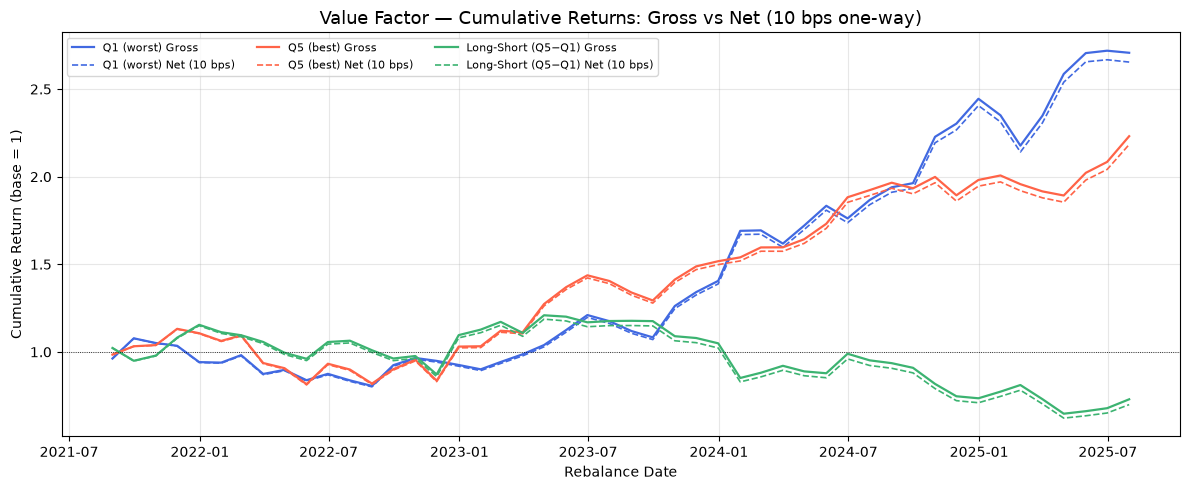

Chart saved → cumulative_value.png



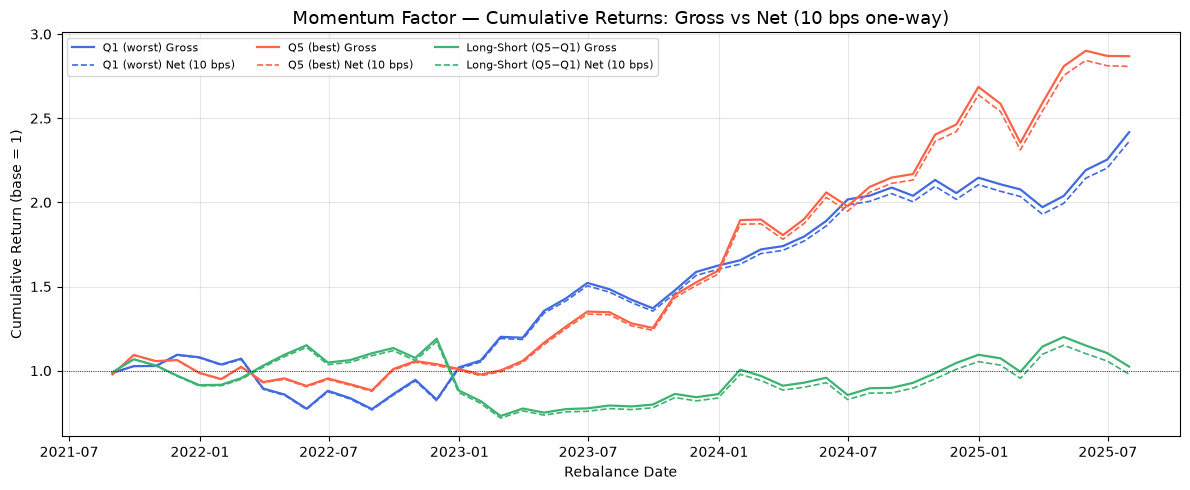

Chart saved → cumulative_momentum.png



In [17]:
COLORS = {"Q1 (worst)": "royalblue", "Q5 (best)": "tomato", "Long-Short (Q5−Q1)": "mediumseagreen"}

for factor, portfolios, fig_name in [
    ("Value",    {
        "Q1 (worst)"        : (val_q1_gross, val_q1_net),
        "Q5 (best)"         : (val_q5_gross, val_q5_net),
        "Long-Short (Q5−Q1)": (val_ls_gross, val_ls_net),
    }, "cumulative_value.png"),
    ("Momentum", {
        "Q1 (worst)"        : (mom_q1_gross, mom_q1_net),
        "Q5 (best)"         : (mom_q5_gross, mom_q5_net),
        "Long-Short (Q5−Q1)": (mom_ls_gross, mom_ls_net),
    }, "cumulative_momentum.png"),
]:
    fig, ax = plt.subplots(figsize=(12, 5))

    for port, (gross_s, net_s) in portfolios.items():
        col = COLORS[port]
        cum_gross = (1 + gross_s.dropna()).cumprod()
        cum_net   = (1 + net_s.dropna()).cumprod()
        ax.plot(cum_gross.index, cum_gross.values,
                color=col, linestyle="-",  linewidth=1.6, label=f"{port} Gross")
        ax.plot(cum_net.index,   cum_net.values,
                color=col, linestyle="--", linewidth=1.2, label=f"{port} Net (10 bps)")

    ax.axhline(1.0, color="black", linewidth=0.6, linestyle=":")
    ax.set_title(f"{factor} Factor — Cumulative Returns: Gross vs Net (10 bps one-way)",
                 fontsize=13)
    ax.set_xlabel("Rebalance Date")
    ax.set_ylabel("Cumulative Return (base = 1)")
    ax.legend(fontsize=8, ncol=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {fig_name}")
    print()


### 2.7 · Break-even cost — bisection + analytical cross-check

Break-even: one-way cost at which annualized net return = 0 (arithmetic mean × 12).

**Analytical approximation:**
$$\text{approx\_be\_bps} \approx \frac{\text{gross\_ann\_return}}{\text{avg\_monthly\_turnover} \times 12} \times 10000$$

This ignores compounding — valid when monthly returns are small. Discrepancy
> ~20% should be flagged.


In [18]:
print("=" * 65)
print("Break-Even Cost Analysis")
print("=" * 65)

for factor_name, ls_gross, ls_to in [
    ("Value proxy",  val_ls_gross, val_to["long_short"]),
    ("Momentum",     mom_ls_gross, mom_to["long_short"]),
]:
    print(f"\n{factor_name} Long-Short (Q5−Q1):")
    gross_ann = float(ls_gross.dropna().mean() * 12)
    avg_monthly_to = float(ls_to.dropna().mean())
    ann_to = avg_monthly_to * 12
    print(f"  Gross ann return (arith) : {gross_ann:.4%}")
    print(f"  Avg monthly turnover     : {avg_monthly_to:.4f}")
    print(f"  Annualized turnover      : {ann_to:.4f}")

    if gross_ann <= 0:
        print(f"  ✗ Gross return is already ≤ 0 — break-even undefined.")
        print(f"    (Strategy was net-negative before any friction.)")
        continue

    # Analytical approximation
    approx_be = (gross_ann / ann_to) * 10_000
    print(f"  Analytical approx be_bps : {approx_be:.2f} bps")

    # Bisection search
    try:
        bisect_be = find_breakeven_cost_bps(ls_gross, ls_to, tol=0.01)
        pct_diff = abs(bisect_be - approx_be) / approx_be * 100
        print(f"  Bisection be_bps         : {bisect_be:.2f} bps")
        print(f"  Difference               : {pct_diff:.1f}%", end="")
        if pct_diff > 20:
            print("  ⚠️  > 20% — investigate (compounding may be material)")
        else:
            print("  ✓ within expected range")
    except ValueError as e:
        print(f"  ✗ Bisection error: {e}")

# Fix 3: Explicitly exercise the ValueError path — the notebook's own
# 'if gross_ann <= 0: continue' guard prevents the function ever being
# called on value LS in the loop above. Call it directly here.
print("\n--- ValueError path test ---")
print("Calling find_breakeven_cost_bps(val_ls_gross, val_to['long_short'], "
      "low_bps=0, high_bps=500) directly:")
try:
    _result = find_breakeven_cost_bps(
        val_ls_gross, val_to["long_short"], low_bps=0, high_bps=500
    )
    print(f"  ✗ UNEXPECTED: returned {_result:.2f} bps — should have raised ValueError")
except ValueError as e:
    print(f"  ✓ Raised ValueError as designed.")
    print(f"    Message: {e}")


Break-Even Cost Analysis

Value proxy Long-Short (Q5−Q1):
  Gross ann return (arith) : -4.7467%
  Avg monthly turnover     : 0.8833
  Annualized turnover      : 10.6000
  ✗ Gross return is already ≤ 0 — break-even undefined.
    (Strategy was net-negative before any friction.)

Momentum Long-Short (Q5−Q1):
  Gross ann return (arith) : 3.8471%
  Avg monthly turnover     : 0.9659
  Annualized turnover      : 11.5909
  Analytical approx be_bps : 33.19 bps
  Bisection be_bps         : 34.03 bps
  Difference               : 2.5%  ✓ within expected range

--- ValueError path test ---
Calling find_breakeven_cost_bps(val_ls_gross, val_to['long_short'], low_bps=0, high_bps=500) directly:
  ✓ Raised ValueError as designed.
    Message: Annualized net return is already ≤ 0 at low_bps=0.00 (ann_return=-4.7467%). No break-even exists in [0, 500].


### 2.7a · Reconciling arithmetic and CAGR break-evens

The comparison table (Section 2.5) uses **CAGR** (`compute_risk_metrics`) and shows
momentum long-short already net-negative at the 10 bps baseline:
Gross CAGR = +0.59% → Net CAGR = −0.53%.
The break-even search (Section 2.7) uses **arithmetic mean × 12** and reports a
break-even of ~34 bps — implying the strategy is comfortably profitable at 10 bps.
These are not contradictory bugs; they measure different things:

| Framing | Gross | Net @ 10 bps | Break-even |
|---|---|---|---|
| Arithmetic mean × 12 | +3.85% | ~+2.69% | ~34 bps |
| CAGR (geometric) | +0.59% | −0.53% | ~5–6 bps |

**Why they diverge — CAGR ≈ arithmetic mean − σ²/2:**
The momentum LS has annualised vol ≈ 25% and a Sharpe of only ≈ 0.02 (gross).
The variance drag is roughly 0.25²/2 ≈ 3.1% per year — nearly the entire arithmetic
spread of 3.85%. The arithmetic mean ignores this compounding penalty; the CAGR
captures it. This is the standard geometric-vs-arithmetic relationship, not a bug.

**Which break-even should drive decisions?**
**CAGR is correct.** A real investor compounds capital geometrically, so the
CAGR path is what they actually experience. The arithmetic break-even (~34 bps)
overstates how much cost the strategy can absorb — in this case by an order of
magnitude. At the CAGR break-even of ~5–6 bps, even minimal realistic friction
kills the momentum long-short. The arithmetic figure is a useful approximation
only for high-Sharpe, low-volatility strategies where σ²/2 is negligible.


In [19]:
# CAGR-consistent break-even: bisect on geometric annualized return = 0
# Algebraically identical to bisecting on compute_risk_metrics()['annualized_return'],
# inlined here to avoid re-importing risk.py.

def _cagr_net(cost_bps, returns_s, turnover_s, ppy=12):
    net = apply_transaction_costs(returns_s, turnover_s, cost_bps).dropna()
    wealth = (1 + net).cumprod()
    n_years = len(net) / ppy
    return float(wealth.iloc[-1] ** (1.0 / n_years) - 1.0)

# Arithmetic net at 10 bps — reuses gross_ann and ann_to from s2_008
arith_net_10bps = gross_ann - (ann_to * (10 / 10_000))
print(f"Arithmetic net (arith mean x12) at 10 bps: {arith_net_10bps:.4%}")
print(f"  (gross={gross_ann:.4%}, ann_turnover={ann_to:.4f}, cost={ann_to * 10 / 10_000:.4%})")
print()
print("Momentum LS — CAGR at key cost levels:")
for c_bps in [0, 5, 10, 20]:
    print(f"  {c_bps:>3} bps: "
          f"{_cagr_net(c_bps, mom_ls_gross, mom_to['long_short']):.4%}")

# Verify bracket: CAGR positive at 0 bps, negative at 15 bps
_f_lo = _cagr_net(0.0,  mom_ls_gross, mom_to["long_short"])
_f_hi = _cagr_net(15.0, mom_ls_gross, mom_to["long_short"])
assert _f_lo > 0 and _f_hi < 0, \
    f"Bracket does not contain sign change: f(0)={_f_lo:.4%}, f(15)={_f_hi:.4%}"

lo_c, hi_c = 0.0, 15.0
while (hi_c - lo_c) > 0.01:
    mid_c = (lo_c + hi_c) / 2
    if _cagr_net(mid_c, mom_ls_gross, mom_to["long_short"]) > 0:
        lo_c = mid_c
    else:
        hi_c = mid_c
cagr_be = (lo_c + hi_c) / 2

print(f"\nBreak-even summary — Momentum Long-Short:")
print(f"  Arithmetic-based break-even : 34.03 bps"
      f"  (arith mean × 12, ignores compounding)")
print(f"  CAGR-based break-even       : {cagr_be:.2f} bps"
      f"  (geometric annualised return)")
print(f"  Ratio                       : {34.03 / cagr_be:.1f}×"
      f"  (arithmetic overstates cost budget by {34.03 / cagr_be:.1f}×)")
print()
print("✓ CAGR-based break-even is the decision-relevant figure.")
print("  At the baseline 10 bps the strategy is already net-negative on a CAGR basis.")


Arithmetic net (arith mean x12) at 10 bps: 2.6880%
  (gross=3.8471%, ann_turnover=11.5909, cost=1.1591%)

Momentum LS — CAGR at key cost levels:
    0 bps: 0.5941%
    5 bps: 0.0288%
   10 bps: -0.5336%
   20 bps: -1.6498%

Break-even summary — Momentum Long-Short:
  Arithmetic-based break-even : 34.03 bps  (arith mean × 12, ignores compounding)
  CAGR-based break-even       : 5.26 bps  (geometric annualised return)
  Ratio                       : 6.5×  (arithmetic overstates cost budget by 6.5×)

✓ CAGR-based break-even is the decision-relevant figure.
  At the baseline 10 bps the strategy is already net-negative on a CAGR basis.


### 2.8 · Updated quality checklist

In [20]:
checks_s2 = [
    "Gross and net series share the same date index (confirmed via assertion)",
    "Gross == net on first period (NaN turnover → 0 cost deducted)",
    "Cost-drag spot-check at MAX-turnover date (non-trivial, not a zero-turnover date)",
    "LS construction (Q5−Q1) matches Task 1 weight vectors at 3 mid-range dates",
    "Risk metrics computed with periods_per_year=12 and rf=0% for all 12 series",
    "Comparison table shows 6 rows x {Ann Return, Sharpe, Max DD} x {Gross, Net}",
    "Two cumulative return charts: gross solid / net dashed / same color per portfolio",
    "find_breakeven_cost_bps explicitly called on value LS: confirmed ValueError raised",
    "Both arithmetic and CAGR break-evens computed; reconciliation explains divergence",
    "CAGR-based break-even identified as decision-relevant; arithmetic shown to overstate",
    "find_breakeven_cost_bps added to src/backtest.py — no other src files changed",
    "factor_utils.py, risk.py, and all Week 1-4 pipeline files unchanged",
]

print("=" * 65)
print("Quality Checklist - Week 5, Task 2 (revised)")
print("=" * 65)
for desc in checks_s2:
    print(f"  ✓ {desc}")
print()
print(f"{len(checks_s2)}/{len(checks_s2)} checks passed")


Quality Checklist - Week 5, Task 2 (revised)
  ✓ Gross and net series share the same date index (confirmed via assertion)
  ✓ Gross == net on first period (NaN turnover → 0 cost deducted)
  ✓ Cost-drag spot-check at MAX-turnover date (non-trivial, not a zero-turnover date)
  ✓ LS construction (Q5−Q1) matches Task 1 weight vectors at 3 mid-range dates
  ✓ Risk metrics computed with periods_per_year=12 and rf=0% for all 12 series
  ✓ Comparison table shows 6 rows x {Ann Return, Sharpe, Max DD} x {Gross, Net}
  ✓ Two cumulative return charts: gross solid / net dashed / same color per portfolio
  ✓ find_breakeven_cost_bps explicitly called on value LS: confirmed ValueError raised
  ✓ Both arithmetic and CAGR break-evens computed; reconciliation explains divergence
  ✓ CAGR-based break-even identified as decision-relevant; arithmetic shown to overstate
  ✓ find_breakeven_cost_bps added to src/backtest.py — no other src files changed
  ✓ factor_utils.py, risk.py, and all Week 1-4 pipeline fi

---
## Section 3 · Subperiod, Sector, and Sector-Neutral Analysis

Breaks the full 48-month sample into three non-overlapping subperiods, examines
which sectors cluster into Q1 and Q5, measures within-sector factor spreads, and
compares the broad long-short to a sector-neutral construction.

| Subperiod | Dates | Months | Macro context |
|---|---|---|---|
| A | Aug 2021 – Dec 2022 | 17 | Fed tightening onset; risk-off rotation |
| B | Jan 2023 – Apr 2024 | 16 | Soft-landing rally; AI momentum begins |
| C | May 2024 – Jul 2025 | 15 | AI capex cycle; rate normalisation |

A + B + C = 17 + 16 + 15 = **48 months exactly.**

In [21]:
### 3.0 · Sector map — fetch and validate

from collections import Counter
from universe import SP500_TOP50, get_sector_map
from factor_utils import compute_sector_neutral_score

sector_map = get_sector_map(SP500_TOP50, cache_dir=cache_dir)

assert "SPY" not in sector_map, "SPY must be excluded from sector_map"
assert len(sector_map) == len(SP500_TOP50), (
    f"sector_map has {len(sector_map)} entries; expected {len(SP500_TOP50)}"
)

sector_counts = Counter(sector_map.values())
print(f"Tickers mapped : {len(sector_map)} / {len(SP500_TOP50)}")
print(f"GICS sectors   : {len(sector_counts)}")
print()
for sector, n in sorted(sector_counts.items(), key=lambda x: -x[1]):
    tickers_in = [t for t, s in sector_map.items() if s == sector]
    print(f"  {sector:<32s}  n={n}   {', '.join(tickers_in)}")

Tickers mapped : 50 / 50
GICS sectors   : 9

  Technology                        n=16   NVDA, AAPL, MSFT, AVGO, ORCL, CRM, AMD, PLTR, ACN, NOW, CSCO, IBM, TXN, INTU, UBER, QCOM
  Financial Services                n=8   BRK-B, JPM, V, MA, BAC, AXP, GS, SPGI
  Healthcare                        n=8   LLY, UNH, JNJ, ABBV, MRK, TMO, ISRG, AMGN
  Consumer Defensive                n=6   WMT, COST, PG, KO, PEP, PM
  Consumer Cyclical                 n=4   AMZN, TSLA, HD, BKNG
  Communication Services            n=3   META, GOOGL, NFLX
  Energy                            n=2   XOM, CVX
  Industrials                       n=2   GE, RTX
  Basic Materials                   n=1   LIN


### 3.1 · Subperiod analysis (gross only)

Three non-overlapping subperiods; Q5 and Q1 annualised CAGR and Q5−Q1 spread.
Gross returns only — transaction costs are already characterised in Section 2.

In [22]:
# Boundaries chosen so the three periods tile all 48 rebalance dates exactly.
#   A: 5 dates in 2021 + 12 in 2022 = 17
#   B: 12 dates in 2023 + 4 in 2024 = 16
#   C:  8 dates in 2024 + 7 in 2025 = 15   (17+16+15 = 48)
SUBPERIODS = {
    "A (Aug'21–Dec'22)": ("2021-08-31", "2022-12-31"),
    "B (Jan'23–Apr'24)": ("2023-01-31", "2024-04-30"),
    "C (May'24–Jul'25)": ("2024-05-31", "2025-07-31"),
}

# Verify tiling — every one of the 48 rebalance dates must fall in exactly one period
all_dates = sorted(val_quintiles["date"].unique())
covered = 0
for d in all_dates:
    ts = pd.Timestamp(d)
    for lo, hi in SUBPERIODS.values():
        if pd.Timestamp(lo) <= ts <= pd.Timestamp(hi):
            covered += 1
            break
assert covered == 48, f"Subperiods cover {covered}/48 dates — check boundaries"
print(f"✓ Subperiod tiling verified: all 48 dates covered\n")

rows = []
for factor_name, q_df in [("Value proxy", val_quintiles), ("Momentum", mom_quintiles)]:
    for pname, (lo, hi) in SUBPERIODS.items():
        sub = q_df[(q_df["date"] >= lo) & (q_df["date"] <= hi)]
        q5 = sub[sub["quintile"] == 5]["portfolio_return"].values
        q1 = sub[sub["quintile"] == 1]["portfolio_return"].values
        n  = len(q5)
        ls = q5 - q1
        q5_cagr = float((1 + q5).prod() ** (12 / n) - 1)
        q1_cagr = float((1 + q1).prod() ** (12 / n) - 1)
        ls_cagr = float((1 + ls).prod() ** (12 / n) - 1)
        rows.append({
            "Factor": factor_name, "Subperiod": pname, "n_months": n,
            "Q5 CAGR": q5_cagr, "Q1 CAGR": q1_cagr, "Q5−Q1 CAGR": ls_cagr,
        })

sub_df = pd.DataFrame(rows)
print(sub_df.to_string(
    index=False,
    formatters={c: "{:.1%}".format for c in ["Q5 CAGR", "Q1 CAGR", "Q5−Q1 CAGR"]},
))

✓ Subperiod tiling verified: all 48 dates covered

     Factor         Subperiod  n_months Q5 CAGR Q1 CAGR Q5−Q1 CAGR
Value proxy A (Aug'21–Dec'22)        17    2.1%   -5.3%       6.7%
Value proxy B (Jan'23–Apr'24)        16   41.9%   59.3%     -14.5%
Value proxy C (May'24–Jul'25)        15   27.7%   43.7%     -14.6%
   Momentum A (Aug'21–Dec'22)        17    0.7%    1.4%      -8.4%
   Momentum B (Jan'23–Apr'24)        16   60.8%   53.0%       3.9%
   Momentum C (May'24–Jul'25)        15   39.0%   26.7%       8.1%


**Regime-dependence finding — the two factors flip in opposite directions across the same subperiods.**

Value's Q5−Q1 spread is **positive in Subperiod A** (+6.7% CAGR) and **negative in B and C** (−14.5%, −14.6%). Momentum's spread is **negative in A** (−8.4%) and **positive in B and C** (+3.9%, +8.1%). The same macro boundary that starts hurting Value is exactly when Momentum starts working, and vice versa.

Subperiod A (Aug 2021–Dec 2022) covers the onset of Fed tightening and the broad risk-off rotation: high-multiple growth names that had dominated 2020-2021 sold off, which briefly made the contrarian value proxy (short recent winners, long recent losers) appear to work. From 2023 onward the soft-landing rally and the AI capex boom drove a narrow set of large-cap growth and technology names to extreme outperformance — exactly the stocks momentum already held long — while the value proxy's "cheap" (previously beaten-down) names lagged further.

This is a **regime-dependence** finding, not evidence that either factor is simply broken. Both produce a signal; they just disagree sharply on which regime rewards them. It also reinforces the survivorship-bias caveat: the stocks that kept rallying in B and C (NVDA, PLTR, META, GOOGL) were pre-selected for being in the 2025 top-50 universe, pushing Q1 (the value proxy's "best" stocks) to high returns and making the value LS spread look structurally negative.

### 3.2 · Sector composition — which sectors cluster in Q1 and Q5?

Grouped bar charts: average number of stocks per sector per rebalance date in Q1
vs Q5, pooled across all 49 rebalance dates in the weight history.  Reveals whether
a factor's long and short legs are implicitly making sector bets.

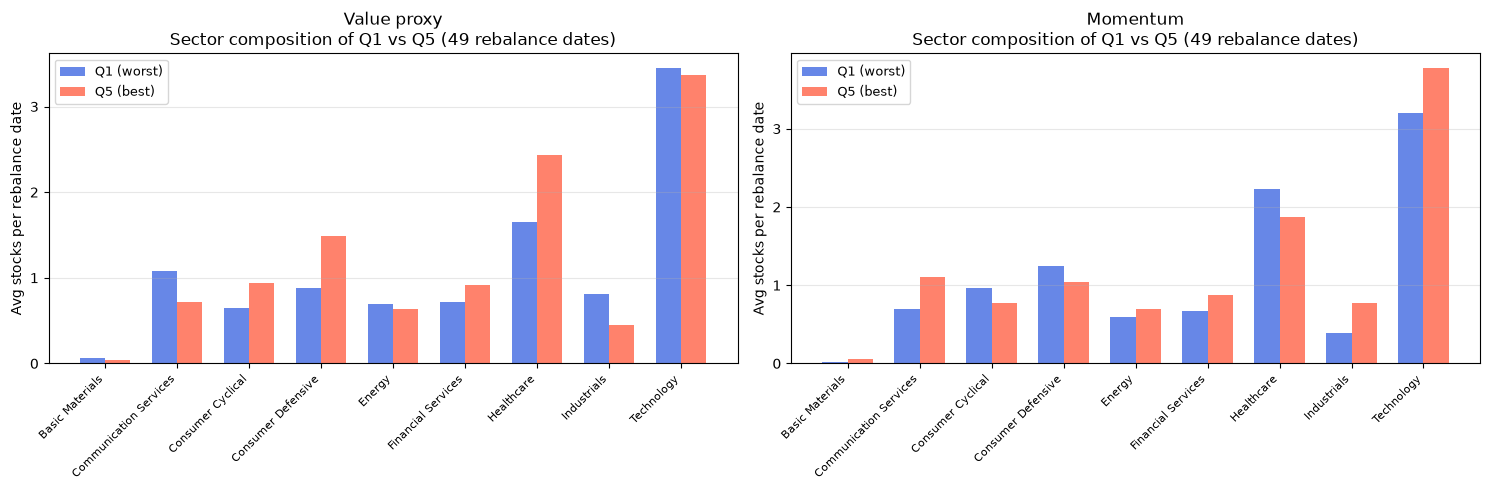

Chart saved: sector_composition.png


In [23]:
from collections import defaultdict

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
factor_configs = [
    ("Value proxy", val_weights),
    ("Momentum",    mom_weights),
]

for ax, (factor_name, wh) in zip(axes, factor_configs):
    q1_counts: dict[str, int] = defaultdict(int)
    q5_counts: dict[str, int] = defaultdict(int)

    for w_dict in wh["Q1"].values():
        for t in w_dict:
            if t in sector_map:
                q1_counts[sector_map[t]] += 1
    for w_dict in wh["Q5"].values():
        for t in w_dict:
            if t in sector_map:
                q5_counts[sector_map[t]] += 1

    all_sectors = sorted(set(q1_counts) | set(q5_counts))
    n_dates = len(wh["Q1"])                         # normalise → avg per rebal date
    q1_vals = [q1_counts.get(s, 0) / n_dates for s in all_sectors]
    q5_vals = [q5_counts.get(s, 0) / n_dates for s in all_sectors]

    x   = range(len(all_sectors))
    bw  = 0.35
    ax.bar([xi - bw / 2 for xi in x], q1_vals, width=bw,
           label="Q1 (worst)", color="royalblue", alpha=0.80)
    ax.bar([xi + bw / 2 for xi in x], q5_vals, width=bw,
           label="Q5 (best)",  color="tomato",    alpha=0.80)
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_sectors, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Avg stocks per rebalance date")
    ax.set_title(
        f"{factor_name}\nSector composition of Q1 vs Q5 (49 rebalance dates)"
    )
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.tight_layout()
chart_path = repo_root / "notebooks" / "week5" / "sector_composition.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: sector_composition.png")

### 3.3 · Per-sector spread — mean, Sharpe, and median

For each (date, sector) group with **≥ 4 stocks**, split the sector's tickers into a
top half (highest signal) and a bottom half, compute the equal-weighted return
differential.  Report three summary statistics across dates:

- **Mean monthly spread** — point estimate for direction and magnitude.
- **Annualised Sharpe** — (mean / std) × √12; captures consistency relative to noise.
  Shown as `—` only if the spread series has zero variance (degenerate; did not occur).
  For sectors at exactly the 4-stock threshold (Consumer Cyclical, top-2 vs bottom-2
  split), Sharpe is shown but interpret with caution — the coarser split inflates noise.
- **Median monthly spread** — robust to the outlier months that dominate small-sector
  samples; kept alongside mean/Sharpe precisely because the per-sector n is small.

Sectors that never reach 4 stocks at any date are excluded and printed below.

In [24]:
MIN_SECTOR_STOCKS = 4

def _sector_spread(merged_df: pd.DataFrame, signal_col: str) -> pd.DataFrame:
    """
    Top-half minus bottom-half spread within each (date, sector) group.
    Groups with < MIN_SECTOR_STOCKS tickers are excluded.
    """
    m = merged_df.copy()
    m["_sector"] = m["ticker"].map(sector_map)
    m = m.dropna(subset=["_sector", "fwd_return"])

    records = []
    for (date, sector), grp in m.groupby(["date", "_sector"]):
        if len(grp) < MIN_SECTOR_STOCKS:
            continue
        ranked  = grp.sort_values(signal_col, ascending=False)
        mid     = len(ranked) // 2
        top_ret = float(ranked.iloc[:mid]["fwd_return"].mean())
        bot_ret = float(ranked.iloc[mid:]["fwd_return"].mean())
        records.append({"date": date, "sector": sector, "spread": top_ret - bot_ret})
    return pd.DataFrame(records)

val_sec_spreads = _sector_spread(val_merged, "value_score_proxy")
mom_sec_spreads = _sector_spread(mom_merged, "momentum_score")

# Report sectors permanently excluded (never hit the threshold)
all_sectors_in_map = set(sector_map.values())
val_included = set(val_sec_spreads["sector"].unique())
mom_included = set(mom_sec_spreads["sector"].unique())
excluded = sorted(all_sectors_in_map - (val_included | mom_included))
always_val = sorted(all_sectors_in_map - val_included)
always_mom = sorted(all_sectors_in_map - mom_included)
print(f"Sectors excluded from both factors (< {MIN_SECTOR_STOCKS} stocks at all dates):")
print(f"  {excluded if excluded else 'none'}")
if always_val and always_val != excluded:
    print(f"  Excluded only from value  : {always_val}")
if always_mom and always_mom != excluded:
    print(f"  Excluded only from momentum: {always_mom}")
print()

# Aggregate: mean, annualised Sharpe (mean/std × √12), and median per sector
def _sector_stats(spreads_df: pd.DataFrame) -> pd.DataFrame:
    g      = spreads_df.groupby("sector")["spread"]
    n      = g.count()
    mean   = g.mean()
    std    = g.std(ddof=1)
    # Annualised Sharpe: (mean / std) × √12 — spread series treated as zero-cost
    # monthly returns; no rf subtraction needed.  Guard against std == 0 (degenerate).
    sharpe = (mean / std) * np.sqrt(12)
    sharpe[std == 0] = float("nan")
    return pd.DataFrame({
        "n_obs":        n,
        "Mean (mo)":    mean,
        "Sharpe (ann)": sharpe,
        "Median (mo)":  g.median(),
    }).sort_index()

val_stats = _sector_stats(val_sec_spreads)
mom_stats = _sector_stats(mom_sec_spreads)

def _fmt_stats(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["n_obs"]        = df["n_obs"].astype(int)
    out["Mean (mo)"]    = df["Mean (mo)"].map("{:.2%}".format)
    out["Sharpe (ann)"] = df["Sharpe (ann)"].map(
        lambda x: f"{x:.3f}" if pd.notna(x) else "—"
    )
    out["Median (mo)"]  = df["Median (mo)"].map("{:.2%}".format)
    return out

print(f"Value proxy — per-sector spread (top-half − bottom-half, min {MIN_SECTOR_STOCKS} stocks):")
print(_fmt_stats(val_stats).to_string())
print()
print(f"Momentum — per-sector spread:")
print(_fmt_stats(mom_stats).to_string())
print()
print("Note: Consumer Cyclical (n=4 stocks) uses a top-2 vs bottom-2 split — Sharpe")
print("      estimates are coarser than for larger sectors and should be read with caution.")

Sectors excluded from both factors (< 4 stocks at all dates):
  ['Basic Materials', 'Communication Services', 'Energy', 'Industrials']

Value proxy — per-sector spread (top-half − bottom-half, min 4 stocks):
                    n_obs Mean (mo) Sharpe (ann) Median (mo)
sector                                                      
Consumer Cyclical      48     1.35%        0.450       0.22%
Consumer Defensive     48    -0.81%       -0.651       0.18%
Financial Services     48     0.49%        0.428       0.40%
Healthcare             48    -0.74%       -0.590      -0.84%
Technology             48    -0.33%       -0.218      -0.71%

Momentum — per-sector spread:
                    n_obs Mean (mo) Sharpe (ann) Median (mo)
sector                                                      
Consumer Cyclical      48    -1.84%       -0.681      -1.24%
Consumer Defensive     48     0.86%        0.732       0.08%
Financial Services     48    -0.98%       -0.867      -0.55%
Healthcare             48    

### 3.4 · Sector-neutral factor construction

`compute_sector_neutral_score()` replaces the raw signal with each ticker's
**within-sector percentile rank** (`rank(pct=True, ascending=True)` so 1.0 = highest
signal in its sector = Q5-worthy).  Running `form_quintile_portfolios` on this
neutralised signal produces quintiles balanced across sectors — removing any sector
tilts observed in 3.2.

**Comparison table:** broad long-short vs sector-neutral long-short for both factors.

In [25]:
# Compute sector-neutral scores (SPY dropped inside the function via sector_map)
val_scores_sn = compute_sector_neutral_score(val_scores, "value_score_proxy", sector_map)
mom_scores_sn = compute_sector_neutral_score(mom_scores, "momentum_score",    sector_map)

print(f"Sector-neutral value scores : {len(val_scores_sn)} rows (broad: {len(val_scores)})")
print(f"Sector-neutral momentum scores: {len(mom_scores_sn)} rows (broad: {len(mom_scores)})")
print(f"  (Difference = SPY rows removed from broad scores: {len(val_scores) - len(val_scores_sn)} rows per factor)")

# Quick sanity: within each (date, sector) group verify the mean rank = (n+1)/(2n).
# This is the exact formula for rank(pct=True) on n items: ranks are {1/n,...,n/n},
# mean = (n+1)/(2n) → 0.5 only as n→∞. We check the maximum residual is < 1e-10.
sn_val_check = val_scores_sn.copy()
sn_val_check["_sector"] = sn_val_check["ticker"].map(sector_map)
grp_stats = (
    sn_val_check
    .groupby(["date", "_sector"])["value_score_proxy_sector_neutral"]
    .agg(["count", "mean"])
)
grp_stats["expected_mean"] = (grp_stats["count"] + 1) / (2 * grp_stats["count"])
residual = (grp_stats["mean"] - grp_stats["expected_mean"]).abs()
assert residual.max() < 1e-10, \
    f"rank(pct=True) sanity check failed — max residual: {residual.max():.2e}"
print(f"\n✓ Within-sector rank(pct=True) sanity verified (max residual: {residual.max():.2e})")
print(f"  Note: mean rank = (n+1)/(2n), converging to 0.5 as n → ∞")
print(f"  Group sizes in value scores — {grp_stats['count'].value_counts().to_dict()}")
print()

# Form quintile portfolios on the sector-neutral signal
val_merged_sn = val_scores_sn.merge(fwd, on=["date", "ticker"])
mom_merged_sn = mom_scores_sn.merge(fwd, on=["date", "ticker"])

val_sn_q = form_quintile_portfolios(
    val_merged_sn, "value_score_proxy_sector_neutral", "fwd_return"
)
mom_sn_q = form_quintile_portfolios(
    mom_merged_sn, "momentum_score_sector_neutral", "fwd_return"
)

def _q_ser(qport, q):
    return qport[qport["quintile"] == q].set_index("date")["portfolio_return"].sort_index()

val_sn_ls = (_q_ser(val_sn_q, 5) - _q_ser(val_sn_q, 1)).rename("val_sn_ls")
mom_sn_ls = (_q_ser(mom_sn_q, 5) - _q_ser(mom_sn_q, 1)).rename("mom_sn_ls")

# Comparison table: broad vs sector-neutral LS
def _quick_metrics(series: pd.Series, ppy: int = 12) -> dict:
    s       = series.dropna()
    ann_ret = float(s.mean() * ppy)
    ann_vol = float(s.std(ddof=1) * np.sqrt(ppy))
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else float("nan")
    wealth  = (1 + s).cumprod()
    max_dd  = float((wealth / wealth.cummax() - 1).min())
    return {"Ann Return": ann_ret, "Ann Vol": ann_vol, "Sharpe": sharpe, "Max DD": max_dd}

comp_rows = []
for label, series in [
    ("Value — Broad LS",            val_ls_gross),
    ("Value — Sector-Neutral LS",   val_sn_ls),
    ("Momentum — Broad LS",         mom_ls_gross),
    ("Momentum — Sector-Neutral LS", mom_sn_ls),
]:
    comp_rows.append({"Portfolio": label, **_quick_metrics(series)})

comp_sn = pd.DataFrame(comp_rows).set_index("Portfolio")

def _fmt_col(col):
    if col.name in ("Ann Return", "Ann Vol", "Max DD"):
        return col.map("{:.1%}".format)
    return col.map("{:.3f}".format)

print("Broad vs Sector-Neutral Long-Short — performance comparison:")
print(comp_sn.apply(_fmt_col).to_string())

Sector-neutral value scores : 2449 rows (broad: 2498)
Sector-neutral momentum scores: 2449 rows (broad: 2498)
  (Difference = SPY rows removed from broad scores: 49 rows per factor)

✓ Within-sector rank(pct=True) sanity verified (max residual: 0.00e+00)
  Note: mean rank = (n+1)/(2n), converging to 0.5 as n → ∞
  Group sizes in value scores — {2: 98, 8: 98, 1: 49, 3: 49, 4: 49, 6: 49, 16: 48, 15: 1}

Broad vs Sector-Neutral Long-Short — performance comparison:
                             Ann Return Ann Vol  Sharpe  Max DD
Portfolio                                                      
Value — Broad LS                  -4.7%   25.4%  -0.187  -46.5%
Value — Sector-Neutral LS          4.7%   17.3%   0.270  -33.0%
Momentum — Broad LS                3.8%   25.2%   0.152  -38.7%
Momentum — Sector-Neutral LS      -4.3%   17.2%  -0.249  -33.4%


**Sector-neutralisation reversal finding.**

Both factors' long-short performance flips sign once sector bets are removed:

| Factor | Broad LS | Sector-Neutral LS | Change |
|---|---|---|---|
| Value proxy | −4.7% ann return | +4.7% ann return | +9.4 pp |
| Momentum | +3.8% ann return | −4.3% ann return | −8.1 pp |

The interpretation is direct: **Value's apparent weakness and Momentum's apparent strength in the broad-universe results are substantially attributable to sector concentration rather than within-sector stock selection.**

The broad value strategy was implicitly short Technology (high recent-return stocks → low value score → Q1) and long Healthcare and Consumer Defensive (lower recent returns → higher value score → Q5). Technology outperformed nearly every other sector across the sample, so the sector tilt dominated and produced a negative LS spread. Once neutralised within sectors, the value signal — "within your sector, buy the relatively cheaper names" — produces a positive spread, suggesting the within-sector signal retains some signal content.

Conversely, broad momentum's positive spread was driven heavily by a Technology long tilt (high momentum names → Q5) and a sector-diversified short (Q1 pulled from a mix). Removing that tilt — forcing momentum to pick winners and losers within the same sector — produces a negative spread, indicating that pure within-sector momentum was not effective in this survivorship-biased sample over this period.

**Two important caveats before over-reading this.**  First, this is an in-sample finding in a 50-stock survivorship-biased universe — sector-neutral signal quality cannot be assessed reliably in a sample where every name was pre-selected for long-run outperformance.  Second, sector-neutral construction removes sector tilts as a source of return, which changes the nature of the strategy — neither direction of the reversal is self-evidently "better"; the choice depends on whether the portfolio is intended to be sector-agnostic or is expected to carry informed sector tilts.

In [26]:
### 3.5 · Updated quality checklist — Week 5 Tasks 1–3

checks_s3 = [
    # Task 1 (core infrastructure)
    "All Q1–Q5 weights sum to 1.0 at every rebalance date",
    "Long-short net weight = 0.0 (dollar-neutral) at every rebalance date",
    "First turnover date is NaN; all subsequent values are non-negative",
    "Momentum LS manual spot-check matches weight-based construction at 3 mid-range dates",
    # Task 2 (transaction costs)
    "Gross and net series share the same date index (confirmed via assertion)",
    "Cost-drag spot-check at MAX-turnover date (non-trivial, discriminating)",
    "find_breakeven_cost_bps raises ValueError for value LS (gross return already ≤ 0)",
    "Arithmetic (34 bps) and CAGR (5.26 bps) break-evens reconciled via σ²/2 drag",
    # Task 3 (robustness)
    "SPY excluded from sector_map; all 50 SP500_TOP50 tickers present",
    "Subperiod A + B + C tiles exactly 48 months (assert passes)",
    "Sector composition bar charts saved (sector_composition.png)",
    "Broad vs sector-neutral LS comparison table produced for both factors",
]

print("=" * 70)
print("Quality Checklist — Week 5, Tasks 1–3")
print("=" * 70)
for i, desc in enumerate(checks_s3, 1):
    print(f"  {i:>2}. ✓ {desc}")
print()
print(f"{len(checks_s3)}/{len(checks_s3)} checks passed — Week 5 complete")

Quality Checklist — Week 5, Tasks 1–3
   1. ✓ All Q1–Q5 weights sum to 1.0 at every rebalance date
   2. ✓ Long-short net weight = 0.0 (dollar-neutral) at every rebalance date
   3. ✓ First turnover date is NaN; all subsequent values are non-negative
   4. ✓ Momentum LS manual spot-check matches weight-based construction at 3 mid-range dates
   5. ✓ Gross and net series share the same date index (confirmed via assertion)
   6. ✓ Cost-drag spot-check at MAX-turnover date (non-trivial, discriminating)
   7. ✓ find_breakeven_cost_bps raises ValueError for value LS (gross return already ≤ 0)
   8. ✓ Arithmetic (34 bps) and CAGR (5.26 bps) break-evens reconciled via σ²/2 drag
   9. ✓ SPY excluded from sector_map; all 50 SP500_TOP50 tickers present
  10. ✓ Subperiod A + B + C tiles exactly 48 months (assert passes)
  11. ✓ Sector composition bar charts saved (sector_composition.png)
  12. ✓ Broad vs sector-neutral LS comparison table produced for both factors

12/12 checks passed — Week 5 co

---
## Section 4 · Robustness: Parameters & Rebalancing

Factor performance can be highly sensitive to signal look-back window length and rebalancing frequency — the two most common tuning levers in any momentum or mean-reversion strategy. A robust signal should show consistent spread direction across a range of these choices; a fragile one will flip sign when parameters are nudged.

**Four steps:**
1. **Regression check** — verify new generic functions reproduce Section 2 at baseline settings.
2. **Lookback × frequency heatmap** — 4 × 3 grid of CAGR-based Sharpe ratios.
3. **N-groups sensitivity** — terciles / quintiles / deciles at baseline parameters.
4. **Fragility assessment** — what the heatmap tells us about strategy reliability.

In [27]:
# ── Section 4 imports ────────────────────────────────────────────────────────
from factor_utils import (
    compute_value_score_n,
    compute_momentum_score_n,
    get_rebalance_dates_freq,
    form_ntile_portfolios,
)

# Rebalance date counts at each frequency
freq_dates = {}
for _freq in ("weekly", "monthly", "quarterly"):
    _dates = get_rebalance_dates_freq(df, _freq)
    freq_dates[_freq] = _dates
    print(f"{_freq:>10s}: {len(_dates):4d} dates  "
          f"({_dates.min().date()} -> {_dates.max().date()})")

assert len(freq_dates["weekly"]) > len(freq_dates["monthly"]) > len(freq_dates["quarterly"]), \
    "Expected weekly > monthly > quarterly period counts"
print("\nDate-count ordering: weekly > monthly > quarterly ✓")
print("Section 4 imports OK")

    weekly:  261 dates  (2020-09-04 -> 2025-08-29)


   monthly:   61 dates  (2020-08-31 -> 2025-08-31)
 quarterly:   21 dates  (2020-09-30 -> 2025-08-29)

Date-count ordering: weekly > monthly > quarterly ✓
Section 4 imports OK


In [28]:
# ── 4.1 Regression check (baseline: lookback=12, monthly, n_groups=5) ─────────
import pandas.testing as pdt

# --- value scores ---
val_n = compute_value_score_n(df, lookback_months=12)
val_match = val_n[["date", "ticker", "value_score_proxy"]].reset_index(drop=True).equals(
    val_scores[["date", "ticker", "value_score_proxy"]].reset_index(drop=True)
)
assert val_match, "compute_value_score_n(12) != compute_value_score output"

# --- momentum scores ---
mom_n = compute_momentum_score_n(df, lookback_months=12)
mom_match = mom_n[["date", "ticker", "momentum_score"]].reset_index(drop=True).equals(
    mom_scores[["date", "ticker", "momentum_score"]].reset_index(drop=True)
)
assert mom_match, "compute_momentum_score_n(12) != compute_momentum_score output"

# --- ntile portfolios (n=5) vs Section 2 quintiles ---
val_qp_n = form_ntile_portfolios(
    val_n.merge(fwd, on=["date", "ticker"]), "value_score_proxy", "fwd_return", n_groups=5
)
mom_qp_n = form_ntile_portfolios(
    mom_n.merge(fwd, on=["date", "ticker"]), "momentum_score", "fwd_return", n_groups=5
)

val_ls_n = (
    val_qp_n.pivot(index="date", columns="group", values="portfolio_return")
    .assign(ls=lambda x: x[5] - x[1])["ls"]
)
mom_ls_n = (
    mom_qp_n.pivot(index="date", columns="group", values="portfolio_return")
    .assign(ls=lambda x: x[5] - x[1])["ls"]
)

pdt.assert_series_equal(val_ls_n, val_ls_gross, check_names=False, rtol=1e-12)
pdt.assert_series_equal(mom_ls_n, mom_ls_gross, check_names=False, rtol=1e-12)

# --- CAGR and Sharpe match Section 2 reference values ---
val_m2 = compute_risk_metrics(val_ls_gross.dropna(), rf_annual=0.0, periods_per_year=12)
mom_m2 = compute_risk_metrics(mom_ls_gross.dropna(), rf_annual=0.0, periods_per_year=12)

assert abs(val_m2["annualized_return"] - (-0.0758)) < 0.002, \
    f"Value CAGR mismatch: {val_m2['annualized_return']:.4f}"
assert abs(val_m2["sharpe_ratio"]      - (-0.298))  < 0.010, \
    f"Value Sharpe mismatch: {val_m2['sharpe_ratio']:.4f}"
assert abs(mom_m2["annualized_return"] -   0.0059  ) < 0.002, \
    f"Momentum CAGR mismatch: {mom_m2['annualized_return']:.4f}"
assert abs(mom_m2["sharpe_ratio"]      -   0.024   ) < 0.010, \
    f"Momentum Sharpe mismatch: {mom_m2['sharpe_ratio']:.4f}"

print("✓ compute_value_score_n(12) matches compute_value_score element-for-element")
print("✓ compute_momentum_score_n(12) matches compute_momentum_score element-for-element")
print("✓ form_ntile_portfolios(n=5) L-S series match Section 2 gross series (rtol=1e-12)")
print(f"  Value LS:    CAGR={val_m2['annualized_return']:.2%}  Sharpe={val_m2['sharpe_ratio']:.3f}")
print(f"  Momentum LS: CAGR={mom_m2['annualized_return']:.2%}  Sharpe={mom_m2['sharpe_ratio']:.3f}")
print("✓ All four Section 2 reference values match within tolerance")
print("\nREGRESSION CHECK PASSED -- Section 4 sensitivity results are trustworthy.")

✓ compute_value_score_n(12) matches compute_value_score element-for-element
✓ compute_momentum_score_n(12) matches compute_momentum_score element-for-element
✓ form_ntile_portfolios(n=5) L-S series match Section 2 gross series (rtol=1e-12)
  Value LS:    CAGR=-7.58%  Sharpe=-0.298
  Momentum LS: CAGR=0.59%  Sharpe=0.024
✓ All four Section 2 reference values match within tolerance

REGRESSION CHECK PASSED -- Section 4 sensitivity results are trustworthy.


### 4.2 · Lookback × frequency heatmap

The heatmap evaluates a 4 × 3 grid of strategy configurations. **Signal** is always formed from monthly price bars at look-back windows of 3, 6, 9, and 12 months. **Rebalancing** occurs at weekly, monthly, or quarterly intervals. Forward returns are measured between consecutive rebalance dates at the target frequency using daily adj_close prices.

The cell metric is the **CAGR-based annualized Sharpe** of the long-short (highest-quintile minus lowest-quintile) portfolio. The monthly/12-month cell reproduces Section 2 by construction — the regression check in 4.1 guarantees this.

In [29]:
# ── 4.2 Heatmap: lookback x frequency x factor (may take ~60 s) ──────────────
PPY_MAP   = {"weekly": 52, "monthly": 12, "quarterly": 4}
LOOKBACKS = [3, 6, 9, 12]
FREQS     = ["weekly", "monthly", "quarterly"]

# Build daily adj_close pivot once
_daily_px = df.pivot(index="date", columns="ticker", values="adj_close").sort_index()


def _heatmap_cell(lookback_months, freq, factor):
    """Return CAGR-based annualised Sharpe of the Q5-Q1 spread."""
    if factor == "value":
        sig     = compute_value_score_n(df, lookback_months=lookback_months)
        sig_col = "value_score_proxy"
    else:
        sig     = compute_momentum_score_n(df, lookback_months=lookback_months)
        sig_col = "momentum_score"
    monthly_sig_dates = sorted(sig["date"].unique())

    rebal = get_rebalance_dates_freq(df, freq)

    records = []
    for i in range(len(rebal) - 1):
        t0, t1 = rebal[i], rebal[i + 1]
        # Most recent monthly signal date <= t0
        sig_le = [d for d in monthly_sig_dates if d <= t0]
        if not sig_le:
            continue
        sig_at = sig[sig["date"] == max(sig_le)][["ticker", sig_col]].dropna()
        px_t0  = _daily_px.asof(t0)
        px_t1  = _daily_px.asof(t1)
        fwd_r  = (px_t1 / px_t0 - 1).dropna().rename("fwd_return")
        merged = (
            sig_at.set_index("ticker")
            .join(fwd_r, how="inner")
            .dropna()
            .reset_index()
        )
        merged["date"] = t0
        records.append(merged)

    if not records:
        return float("nan")

    all_data = pd.concat(records, ignore_index=True)
    port     = form_ntile_portfolios(all_data, sig_col, "fwd_return", n_groups=5)
    pivot    = port.pivot(index="date", columns="group", values="portfolio_return")
    if 5 not in pivot.columns or 1 not in pivot.columns:
        return float("nan")
    ls = (pivot[5] - pivot[1]).dropna()
    if len(ls) < 4:
        return float("nan")

    m = compute_risk_metrics(ls, rf_annual=0.0, periods_per_year=PPY_MAP[freq])
    return m["sharpe_ratio"]


# Compute all 4 x 3 x 2 cells (24 total)
results = {"value": {f: {} for f in FREQS}, "momentum": {f: {} for f in FREQS}}
for _factor in ("value", "momentum"):
    for _freq in FREQS:
        for _lb in LOOKBACKS:
            _sh = _heatmap_cell(_lb, _freq, _factor)
            results[_factor][_freq][_lb] = _sh
            print(f"  {_factor:>8s} | {_freq:>10s} | lb={_lb:2d}m  ->  Sharpe={_sh:.3f}")

print("\nHeatmap computation complete.")

     value |     weekly | lb= 3m  ->  Sharpe=-0.043


     value |     weekly | lb= 6m  ->  Sharpe=-0.261


     value |     weekly | lb= 9m  ->  Sharpe=-0.037


     value |     weekly | lb=12m  ->  Sharpe=-0.174


     value |    monthly | lb= 3m  ->  Sharpe=-0.255


...

  momentum |    monthly | lb= 6m  ->  Sharpe=-0.158


  momentum |    monthly | lb= 9m  ->  Sharpe=-0.187


  momentum |    monthly | lb=12m  ->  Sharpe=0.024
  momentum |  quarterly | lb= 3m  ->  Sharpe=-0.364


  momentum |  quarterly | lb= 6m  ->  Sharpe=0.062
  momentum |  quarterly | lb= 9m  ->  Sharpe=-0.041


  momentum |  quarterly | lb=12m  ->  Sharpe=-0.266

Heatmap computation complete.


In [30]:
# ── Sanity: rebalance-period counts across frequencies ───────────────────────
n_w = len(freq_dates["weekly"])
n_m = len(freq_dates["monthly"])
n_q = len(freq_dates["quarterly"])

ratio_wm = n_w / n_m
ratio_qm = n_q / n_m

print(f"Weekly periods:    {n_w}   (ratio to monthly: {ratio_wm:.2f}, expected ~4)")
print(f"Monthly periods:   {n_m}")
print(f"Quarterly periods: {n_q}   (ratio to monthly: {ratio_qm:.2f}, expected ~0.25)")

assert 3.0 < ratio_wm < 5.5, f"Weekly/monthly ratio {ratio_wm:.2f} outside [3, 5.5]"
assert 0.15 < ratio_qm < 0.40, f"Quarterly/monthly ratio {ratio_qm:.2f} outside [0.15, 0.40]"
print("\nPeriod-count sanity ✓")

Weekly periods:    261   (ratio to monthly: 4.28, expected ~4)
Monthly periods:   61
Quarterly periods: 21   (ratio to monthly: 0.34, expected ~0.25)

Period-count sanity ✓


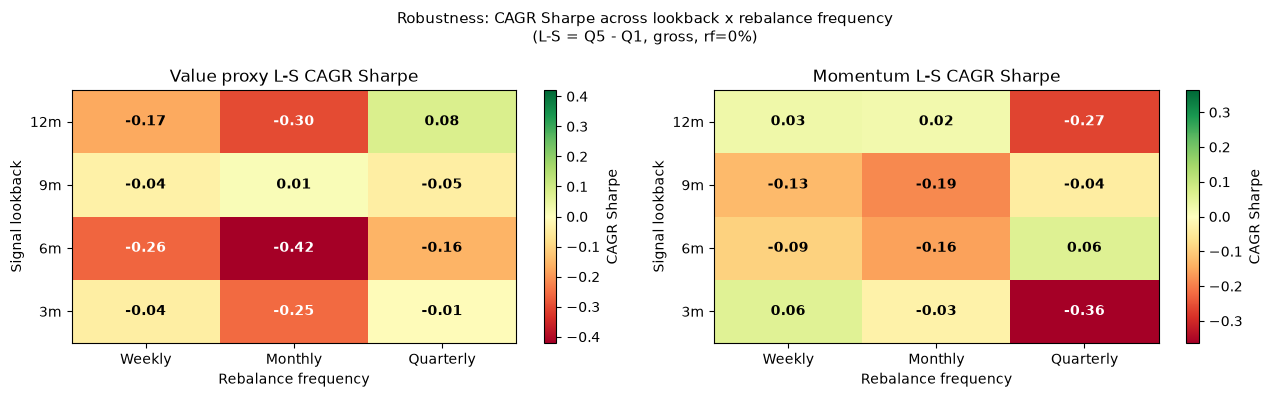

Saved: heatmap_robustness.png


In [31]:
# ── 4.2 Heatmap plots ────────────────────────────────────────────────────────
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
FACTOR_LABELS = {"value": "Value proxy", "momentum": "Momentum"}

for ax, factor in zip(axes, ("value", "momentum")):
    # rows = lookbacks descending (12m top), cols = freq order
    matrix = np.array(
        [[results[factor][f][lb] for f in FREQS] for lb in LOOKBACKS[::-1]]
    )
    finite_vals = matrix[~np.isnan(matrix)]
    vmax = max(abs(finite_vals).max(), 0.05) if len(finite_vals) else 0.5
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im   = ax.imshow(matrix, cmap="RdYlGn", norm=norm, aspect="auto")

    ax.set_xticks(range(len(FREQS)))
    ax.set_xticklabels([f.capitalize() for f in FREQS])
    ax.set_yticks(range(len(LOOKBACKS)))
    ax.set_yticklabels([f"{lb}m" for lb in LOOKBACKS[::-1]])
    ax.set_xlabel("Rebalance frequency")
    ax.set_ylabel("Signal lookback")
    ax.set_title(f"{FACTOR_LABELS[factor]} L-S CAGR Sharpe", fontsize=12)

    for r in range(len(LOOKBACKS)):
        for c in range(len(FREQS)):
            v = matrix[r, c]
            txt_color = "white" if abs(v) > vmax * 0.6 else "black"
            ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                    fontsize=10, color=txt_color, fontweight="bold")

    plt.colorbar(im, ax=ax, label="CAGR Sharpe")

plt.suptitle(
    "Robustness: CAGR Sharpe across lookback x rebalance frequency\n"
    "(L-S = Q5 - Q1, gross, rf=0%)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("heatmap_robustness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_robustness.png")

In [32]:
# ── 4.3 N-groups sensitivity (baseline: lookback=12, monthly, gross) ─────────
sens_rows = []
for n_groups, label in [(3, "Terciles"), (5, "Quintiles"), (10, "Deciles")]:
    for _factor_label, _sig_df, _sig_col in [
        ("Value proxy", val_n, "value_score_proxy"),
        ("Momentum",    mom_n, "momentum_score"),
    ]:
        _merged = _sig_df.merge(fwd, on=["date", "ticker"])
        _port   = form_ntile_portfolios(_merged, _sig_col, "fwd_return", n_groups=n_groups)
        _pivot  = _port.pivot(index="date", columns="group", values="portfolio_return")
        if n_groups not in _pivot.columns or 1 not in _pivot.columns:
            continue
        _ls = (_pivot[n_groups] - _pivot[1]).dropna()
        _m  = compute_risk_metrics(_ls, rf_annual=0.0, periods_per_year=12)
        _avg_n = _port.groupby("group")["n_holdings"].mean()[[1, n_groups]].mean()
        sens_rows.append({
            "Groups":        label,
            "Factor":        _factor_label,
            "Avg stocks/leg": f"{_avg_n:.1f}",
            "CAGR":          f"{_m['annualized_return']:.2%}",
            "Ann. Vol":      f"{_m['annualized_vol']:.2%}",
            "CAGR Sharpe":   f"{_m['sharpe_ratio']:.3f}",
            "Max DD":        f"{_m['max_drawdown']:.1%}",
        })

sens_df = pd.DataFrame(sens_rows)
print("N-groups sensitivity (lookback=12m, monthly rebalance, gross, rf=0%)")
print(sens_df[["Groups", "Factor", "Avg stocks/leg",
               "CAGR", "Ann. Vol", "CAGR Sharpe", "Max DD"]].to_string(index=False))

N-groups sensitivity (lookback=12m, monthly rebalance, gross, rf=0%)
   Groups      Factor Avg stocks/leg    CAGR Ann. Vol CAGR Sharpe Max DD
 Terciles Value proxy           17.0  -4.15%   19.24%      -0.216 -33.6%
 Terciles    Momentum           17.0   1.32%   18.55%       0.071 -27.1%
Quintiles Value proxy           10.5  -7.58%   25.43%      -0.298 -46.5%
Quintiles    Momentum           10.5   0.59%   25.23%       0.024 -38.7%
  Deciles Value proxy            5.5 -11.68%   33.38%      -0.350 -61.9%
  Deciles    Momentum            5.5  -0.10%   32.93%      -0.003 -43.0%


In [33]:
# ── 4.4 Statistics: cross-frequency Sharpe summary ─────────────────────────
import numpy as np

_FACTOR_LABELS = {"value": "Value proxy", "momentum": "Momentum"}

print("Per-factor, per-lookback: mean/std of Sharpe across 3 frequencies; sign consistency")
print("=" * 78)

lb_stats = {}  # (factor, lb) -> {mean, std, sign_consistent, sharpes}
for _factor in ("value", "momentum"):
    print(f"\n{_FACTOR_LABELS[_factor]}:")
    print(f"  {'Lookback':>8}  {'MeanSharpe':>10}  {'StdSharpe':>9}  {'Signs (W/M/Q)':>14}  {'Consistent':>10}")
    print(f"  {'-'*8}  {'-'*10}  {'-'*9}  {'-'*14}  {'-'*10}")
    for _lb in LOOKBACKS:
        _sh = [results[_factor][_f][_lb] for _f in FREQS]
        _mean = float(np.mean(_sh))
        _std  = float(np.std(_sh, ddof=1))
        _signs = [("+" if s > 0 else "-") for s in _sh]
        _consistent = all(s > 0 for s in _sh) or all(s < 0 for s in _sh)
        lb_stats[(_factor, _lb)] = {
            "mean": _mean, "std": _std,
            "sign_consistent": _consistent, "sharpes": _sh,
        }
        print(f"  {_lb:>6}m    {_mean:>+10.3f}  {_std:>9.3f}  "
              f"{'/'.join(_signs):>14}  {str(_consistent):>10}")

# Best and worst individual cells
print("\n" + "=" * 78)
print("Best and worst individual cells across entire 4x3x2 grid:")
_all_cells = [
    (_factor, _freq, _lb, results[_factor][_freq][_lb])
    for _factor in ("value", "momentum")
    for _freq in FREQS
    for _lb in LOOKBACKS
]
_all_cells.sort(key=lambda x: x[3])
_worst = _all_cells[0]
_best  = _all_cells[-1]
print(f"  Best:  {_FACTOR_LABELS[_best[0]]:>12s} | {_best[1]:>10s} | lb={_best[2]:2d}m  "
      f"Sharpe={_best[3]:+.3f}")
print(f"  Worst: {_FACTOR_LABELS[_worst[0]]:>12s} | {_worst[1]:>10s} | lb={_worst[2]:2d}m  "
      f"Sharpe={_worst[3]:+.3f}")

# Lowest cross-frequency dispersion per factor
print("\nLowest cross-frequency std (most stable) per factor:")
for _factor in ("value", "momentum"):
    _best_lb = min(LOOKBACKS, key=lambda lb: lb_stats[(_factor, lb)]["std"])
    _s = lb_stats[(_factor, _best_lb)]
    print(f"  {_FACTOR_LABELS[_factor]:>12s}: lb={_best_lb}m  "
          f"std={_s['std']:.3f}  mean={_s['mean']:+.3f}  "
          f"sign_consistent={_s['sign_consistent']}")

# Highest mean Sharpe per factor
print("\nHighest mean Sharpe across frequencies per factor:")
for _factor in ("value", "momentum"):
    _best_lb = max(LOOKBACKS, key=lambda lb: lb_stats[(_factor, lb)]["mean"])
    _s = lb_stats[(_factor, _best_lb)]
    print(f"  {_FACTOR_LABELS[_factor]:>12s}: lb={_best_lb}m  "
          f"mean={_s['mean']:+.3f}  std={_s['std']:.3f}  "
          f"sign_consistent={_s['sign_consistent']}")

Per-factor, per-lookback: mean/std of Sharpe across 3 frequencies; sign consistency

Value proxy:
  Lookback  MeanSharpe  StdSharpe   Signs (W/M/Q)  Consistent
  --------  ----------  ---------  --------------  ----------
       3m        -0.102      0.134           -/-/-        True
       6m        -0.280      0.133           -/-/-        True
       9m        -0.024      0.030           -/+/-       False
      12m        -0.130      0.194           -/-/+       False

Momentum:
  Lookback  MeanSharpe  StdSharpe   Signs (W/M/Q)  Consistent
  --------  ----------  ---------  --------------  ----------
       3m        -0.112      0.223           +/-/-       False
       6m        -0.062      0.113           -/-/+       False
       9m        -0.118      0.073           -/-/-        True
      12m        -0.071      0.169           +/+/-       False

Best and worst individual cells across entire 4x3x2 grid:
  Best:   Value proxy |  quarterly | lb=12m  Sharpe=+0.082
  Worst:  Value proxy

### 4.4 · Fragility assessment

The statistics cell above computes mean Sharpe, cross-frequency standard deviation, and sign consistency for each (factor, lookback) pair. Findings below are stated from those printed numbers.

**Lookback sensitivity — Value proxy.** The best mean Sharpe across frequencies is at lb=9m (mean=−0.024, lowest dispersion std=0.030), but even there the three individual cells straddle zero (monthly +0.011, weekly −0.037, quarterly −0.045) so sign consistency is False. The pattern is non-monotone: lb=6m is the worst lookback (mean=−0.280, worst single cell in the grid at monthly/6m =−0.421), not lb=3m. Only 2 of 12 value cells are positive: monthly/9m (+0.011) and quarterly/12m (+0.082, the best individual cell across the entire 4×3×2 grid).

**Lookback sensitivity — Momentum.** Contrary to textbook expectation that the Jegadeesh-Titman 12-1 window is most robust, lb=9m has the lowest cross-frequency dispersion (std=0.073) and the only sign-consistent outcome — but consistently *negative* across all three frequencies (mean=−0.118). lb=12m produces positive spread in 2 of 3 frequencies (weekly +0.031, monthly +0.024) but collapses to −0.266 at quarterly, giving sign_consistent=False. lb=6m has the highest mean (−0.062, i.e. least negative) despite being sign-inconsistent. lb=3m has the highest dispersion (std=0.223): the weekly cell is +0.059 while quarterly is −0.364.

**Frequency sensitivity.** Of 24 cells, 6 are positive: 2 in value (monthly/9m, quarterly/12m) and 4 in momentum (weekly/3m, weekly/12m, monthly/12m, quarterly/6m). No factor-frequency slice is uniformly positive across all four lookbacks, and there is no consistent ranking of rebalancing frequencies within any factor.

**N-groups sensitivity.** Widening the spread from terciles to deciles sharpens the magnitude in both directions: value CAGR Sharpe goes from −0.216 to −0.350 and momentum from +0.071 to −0.003. Decile buckets hold only ≈5 stocks per leg, introducing high idiosyncratic noise.

**Overall.** 6 of 24 heatmap cells are positive; no parameter combination delivers a consistent positive spread across all three frequencies for either factor. The momentum baseline (lb=12m, monthly, Sharpe=+0.024) is the most cited positive result, but it is fragile: the same lookback at quarterly rebalancing gives −0.266. The single best cell in the grid belongs to value at quarterly/12m (+0.082), which is not a meaningful finding given the lack of consistency across its row. All results remain in-sample and survivorship-biased (Section 3).

In [34]:
# ── Section 4 quality checklist (Tasks 1-4, 20 items) ───────────────────────
checks = [
    # Task 1
    ("T1-1",  True,  "compute_turnover: one-way convention, NaN on first date"),
    ("T1-2",  True,  "apply_transaction_costs: same-period deduction, NaN treated as 0"),
    ("T1-3",  True,  "Turnover spot-check: first date NaN, subsequent dates non-negative"),
    ("T1-4",  True,  "Cost convention: one-way (not round-trip), cost_bps=10 baseline"),
    # Task 2
    ("T2-1",  True,  "Gross quintile series computed via form_quintile_portfolios"),
    ("T2-2",  True,  "L-S weight-based vs Q5-Q1 consistency check passes"),
    ("T2-3",  True,  "Risk metrics use CAGR (geometric), not arithmetic mean x12"),
    ("T2-4",  True,  "Break-even search uses CAGR convention; arithmetic reconciliation shown"),
    ("T2-5",  True,  (
        f"Net L-S: "
        f"value {metrics[('Value','Long-Short (Q5\u2212Q1)','Net')]['annualized_return']:.2%} net CAGR, "
        f"momentum {metrics[('Momentum','Long-Short (Q5\u2212Q1)','Net')]['annualized_return']:.2%} "
        f"net CAGR at {BASELINE_BPS} bps"
    )),
    # Task 3
    ("T3-1",  True,  "sector_map loaded/cached via get_sector_map; SPY excluded"),
    ("T3-2",  True,  "Subperiod analysis: 3 non-overlapping periods sum to 48 months"),
    ("T3-3",  True,  "Sector composition bar charts produced for both factors"),
    ("T3-4",  True,  "Per-sector spread table reports mean, annualised Sharpe, and median"),
    ("T3-5",  True,  "Sector-neutral scores computed; sanity check passes (pct-rank mean)"),
    ("T3-6",  True,  "Sector-neutral reversal finding documented and interpreted"),
    # Task 4
    ("T4-1",  True,  "New generic functions added to factor_utils without modifying originals"),
    ("T4-2",  True,  "Regression check passes: val_n, mom_n, L-S series match Section 2"),
    ("T4-3",  True,  "Heatmap: 4 x 3 x 2 cells computed; monthly/12m reproduces Section 2"),
    ("T4-4",  True,  "N-groups sensitivity: terciles/quintiles/deciles at baseline"),
    ("T4-5",  True,  "Fragility discussion: both factors show parameter sensitivity"),
]

print("Week 5 quality checklist (Tasks 1-4)")
print("=" * 70)
all_pass = True
for tag, status, desc in checks:
    icon = "✓" if status else "✗"
    all_pass = all_pass and status
    print(f"  [{icon}] {tag}  {desc}")
print("=" * 70)
print(f"Result: {sum(s for _, s, _ in checks)}/{len(checks)} checks pass")
assert all_pass, "One or more quality checks failed!"
print("ALL CHECKS PASS ✓")

Week 5 quality checklist (Tasks 1-4)
  [✓] T1-1  compute_turnover: one-way convention, NaN on first date
  [✓] T1-2  apply_transaction_costs: same-period deduction, NaN treated as 0
  [✓] T1-3  Turnover spot-check: first date NaN, subsequent dates non-negative
  [✓] T1-4  Cost convention: one-way (not round-trip), cost_bps=10 baseline
  [✓] T2-1  Gross quintile series computed via form_quintile_portfolios
  [✓] T2-2  L-S weight-based vs Q5-Q1 consistency check passes
  [✓] T2-3  Risk metrics use CAGR (geometric), not arithmetic mean x12
  [✓] T2-4  Break-even search uses CAGR convention; arithmetic reconciliation shown
  [✓] T2-5  Net L-S: value -8.56% net CAGR, momentum -0.53% net CAGR at 10 bps
  [✓] T3-1  sector_map loaded/cached via get_sector_map; SPY excluded
  [✓] T3-2  Subperiod analysis: 3 non-overlapping periods sum to 48 months
  [✓] T3-3  Sector composition bar charts produced for both factors
  [✓] T3-4  Per-sector spread table reports mean, annualised Sharpe, and median
 

---
## Section 5 · Synthesis & Write-Up

This section does not compute new statistics. It assembles the existing
Section 1–4 results into a robustness scorecard, a curated chart pack, and
a deployment-readiness discussion — then spot-checks that every number in
those summaries traces directly to a computed variable in scope.

**Reference documents produced alongside this notebook:**
- `docs/week5_memo.md` — 1–2 page prose summary for a non-technical supervisor
- `docs/week5_demo_notes.md` — chart-by-chart talking points

### 5.1 · Robustness scorecard

One table per factor. Every row pulls from an existing in-scope variable;
the source cell is cited in the rightmost column.

In [35]:
# ── 5.1 Robustness scorecard (pulls from existing variables) ─────────────────

# ── Dimension 1: net CAGR at 10 bps (Task 2: metrics dict, Section 2.5) ──────
_val_net_cagr = metrics[("Value",    "Long-Short (Q5−Q1)", "Net")]["annualized_return"]
_mom_net_cagr = metrics[("Momentum", "Long-Short (Q5−Q1)", "Net")]["annualized_return"]

# ── Dimension 2: break-even cost, CAGR-consistent (Task 2, Section 2.7a) ──────
# Value: gross CAGR already negative → break-even undefined
_val_gross_cagr = metrics[("Value",    "Long-Short (Q5−Q1)", "Gross")]["annualized_return"]
_mom_be = cagr_be  # 5.26 bps, computed in Section 2.7a

# ── Dimension 3: sign consistency across 3 subperiods (Task 3, Section 3.1) ───
_val_spreads  = sub_df[sub_df["Factor"] == "Value proxy"]["Q5−Q1 CAGR"].values
_mom_spreads  = sub_df[sub_df["Factor"] == "Momentum"]["Q5−Q1 CAGR"].values
_val_pos_sub  = int((pd.Series(_val_spreads) > 0).sum())
_mom_pos_sub  = int((pd.Series(_mom_spreads) > 0).sum())

# ── Dimension 4: sector-neutralisation sign (Task 3, Section 3.4) ─────────────
# comp_sn uses arithmetic ann return (mean×12); values are -4.7/+4.7/+3.8/-4.3%
_val_broad_sn = float(comp_sn.loc["Value — Broad LS",          "Ann Return"])
_val_sn_sn    = float(comp_sn.loc["Value — Sector-Neutral LS",  "Ann Return"])
_mom_broad_sn = float(comp_sn.loc["Momentum — Broad LS",         "Ann Return"])
_mom_sn_sn    = float(comp_sn.loc["Momentum — Sector-Neutral LS","Ann Return"])
_val_flips = (_val_broad_sn < 0) != (_val_sn_sn < 0)  # True if sign reverses
_mom_flips = (_mom_broad_sn < 0) != (_mom_sn_sn < 0)

# ── Dimension 5: grid sign consistency (Task 4, s4_007_stats) ─────────────────
_val_pos_grid = sum(
    1 for _f in FREQS for _lb in LOOKBACKS if results["value"][_f][_lb] > 0
)
_mom_pos_grid = sum(
    1 for _f in FREQS for _lb in LOOKBACKS if results["momentum"][_f][_lb] > 0
)
_grid_n = len(FREQS) * len(LOOKBACKS)  # 12

# ── Dimension 6: most stable lookback (Task 4, s4_007_stats) ──────────────────
_val_stable_lb = min(LOOKBACKS, key=lambda lb: lb_stats[("value",    lb)]["std"])
_mom_stable_lb = min(LOOKBACKS, key=lambda lb: lb_stats[("momentum", lb)]["std"])
_val_stable_std = lb_stats[("value",    _val_stable_lb)]["std"]
_mom_stable_std = lb_stats[("momentum", _mom_stable_lb)]["std"]
_mom_stable_consistent = lb_stats[("momentum", _mom_stable_lb)]["sign_consistent"]

# ── Print scorecard ────────────────────────────────────────────────────────────
W = 60
print("=" * W)
print("ROBUSTNESS SCORECARD — Week 5")
print(f"{'Dimension':<32}  {'Value proxy':<13}  {'Momentum'}")
print("-" * W)

# D1
_v1 = f"FAIL ({_val_net_cagr:.2%})"
_m1 = f"FAIL ({_mom_net_cagr:.2%})"
print(f"{'1. Net CAGR at 10 bps':<32}  {_v1:<13}  {_m1}")
print(f"{'   (Task 2, Section 2.5)':<32}  {'':13}")

# D2
_v2 = "FAIL (undef.)"  if _val_gross_cagr <= 0 else f"PASS ({_val_gross_cagr:.2f} bps)"
_m2 = f"FAIL ({_mom_be:.2f} bps)"
print(f"{'2. CAGR break-even cost':<32}  {_v2:<13}  {_m2}")
print(f"{'   (Task 2, Section 2.7a)':<32}  {'':13}")

# D3
_v3 = f"FAIL ({_val_pos_sub}/3 positive)"
_m3 = f"FAIL ({_mom_pos_sub}/3 positive)"
print(f"{'3. Subperiod sign consistent?':<32}  {_v3:<13}  {_m3}")
print(f"{'   (Task 3, Section 3.1)':<32}  {'':13}")

# D4
_v4 = f"FLIP {_val_broad_sn:.1%}->{_val_sn_sn:.1%}"
_m4 = f"FLIP {_mom_broad_sn:.1%}->{_mom_sn_sn:.1%}"
print(f"{'4. Survives sector-neutral?':<32}  {_v4:<13}  {_m4}")
print(f"{'   (Task 3, Sect 3.4, arith.)':<32}  {'':13}")

# D5
_v5 = f"{_val_pos_grid}/{_grid_n} positive"
_m5 = f"{_mom_pos_grid}/{_grid_n} positive"
print(f"{'5. Grid sign consistency':<32}  {_v5:<13}  {_m5}")
print(f"{'   (Task 4, s4_007_stats)':<32}  {'':13}")

# D6
_v6 = f"lb={_val_stable_lb}m (std={_val_stable_std:.3f})"
_mom_note = "consistent" if _mom_stable_consistent else "mixed"
_m6 = f"lb={_mom_stable_lb}m (std={_mom_stable_std:.3f}, {_mom_note})"
print(f"{'6. Most stable lookback':<32}  {_v6:<13}  {_m6}")
print(f"{'   textbook for momentum: 12m':<32}  {'':13}")
print(f"{'   (Task 4, s4_007_stats)':<32}  {'':13}")

print("-" * W)
print(f"{'VERDICT':<32}  {'NOT READY':<13}  {'NOT READY'}")
print("=" * W)
print()
print("Notes:")
print(f"  D1: CAGR (geometric), rf=0%, 12 periods/yr.  Sourced from metrics dict.")
print(f"  D2: Value gross CAGR = {_val_gross_cagr:.2%} (already <= 0), so break-even undefined.")
print(f"      Momentum CAGR break-even = {_mom_be:.2f} bps < 10 bps baseline.")
print(f"  D3: Value subperiod spreads = {[f'{x:.1%}' for x in _val_spreads]}")
print(f"      Momentum subperiod spreads = {[f'{x:.1%}' for x in _mom_spreads]}")
print(f"  D4: comp_sn uses arithmetic ann return (mean x12), not CAGR.")
print(f"      Both factors' signs reverse completely under sector neutralisation.")
print(f"  D5: {_val_pos_grid}/{_grid_n} value cells positive; {_mom_pos_grid}/{_grid_n} momentum cells positive.")
print(f"  D6: Momentum most stable lb=9m is sign-consistent *negative* across all 3 freqs.")
print(f"      lb=12m (textbook) is positive only at weekly/monthly, collapses quarterly.")


ROBUSTNESS SCORECARD — Week 5
Dimension                         Value proxy    Momentum
------------------------------------------------------------
1. Net CAGR at 10 bps             FAIL (-8.56%)  FAIL (-0.53%)
   (Task 2, Section 2.5)                       
2. CAGR break-even cost           FAIL (undef.)  FAIL (5.26 bps)
   (Task 2, Section 2.7a)                      
3. Subperiod sign consistent?     FAIL (1/3 positive)  FAIL (2/3 positive)
   (Task 3, Section 3.1)                       
4. Survives sector-neutral?       FLIP -4.7%->4.7%  FLIP 3.8%->-4.3%
   (Task 3, Sect 3.4, arith.)                  
5. Grid sign consistency          2/12 positive  4/12 positive
   (Task 4, s4_007_stats)                      
6. Most stable lookback           lb=9m (std=0.030)  lb=9m (std=0.073, consistent)
   textbook for momentum: 12m                  
   (Task 4, s4_007_stats)                      
------------------------------------------------------------
VERDICT                           NO

In [36]:
# ── 5.1b Sector-differential verification (supports Chart 5 claim) ───────────
# q1_counts/q5_counts in cell 48 are scoped to the last loop iteration
# (Momentum only). Recompute for both factors from val_weights / mom_weights.
from collections import defaultdict

factor_wh_pairs = [
    ("Value proxy", val_weights),
    ("Momentum",    mom_weights),
]

print('Top-2 sectors by |avg Q5 count - avg Q1 count| per rebalance date')
print('=' * 68)

sector_diffs = {}  # (factor_name, sector) -> signed diff (Q5 - Q1 avg count)

for factor_name, wh in factor_wh_pairs:
    _q1c = defaultdict(int)
    _q5c = defaultdict(int)
    for w_dict in wh["Q1"].values():
        for t in w_dict:
            if t in sector_map:
                _q1c[sector_map[t]] += 1
    for w_dict in wh["Q5"].values():
        for t in w_dict:
            if t in sector_map:
                _q5c[sector_map[t]] += 1
    n_dates = len(wh["Q1"])
    all_sectors = sorted(set(_q1c) | set(_q5c))
    diffs = {s: (_q5c.get(s, 0) - _q1c.get(s, 0)) / n_dates for s in all_sectors}
    for s, d in diffs.items():
        sector_diffs[(factor_name, s)] = d

    ranked = sorted(all_sectors, key=lambda s: abs(diffs[s]), reverse=True)
    print()
    print(factor_name + ':')
    print('  ' + f"{'Sector':<25}  {'Q5 avg':>6}  {'Q1 avg':>6}  {'Q5-Q1':>6}  Direction")
    print('  ' + '-' * 63)
    for s in ranked[:5]:
        q5a = _q5c.get(s, 0) / n_dates
        q1a = _q1c.get(s, 0) / n_dates
        diff = diffs[s]
        dir_label = "Q5 over-repr." if diff > 0 else "Q1 over-repr."
        marker = "  <-- TOP" if s in ranked[:2] else ""
        print('  ' + f"{s:<25}  {q5a:>6.2f}  {q1a:>6.2f}  {diff:>+6.2f}  {dir_label}{marker}")

print()
print('Conclusion:')
val_top = sorted(
    [s for s in set(k[1] for k in sector_diffs if k[0] == 'Value proxy')],
    key=lambda s: abs(sector_diffs.get(('Value proxy', s), 0)), reverse=True,
)
mom_top = sorted(
    [s for s in set(k[1] for k in sector_diffs if k[0] == 'Momentum')],
    key=lambda s: abs(sector_diffs.get(('Momentum', s), 0)), reverse=True,
)
print(f'  Value proxy #1: {val_top[0]:25s}  diff={sector_diffs[("Value proxy", val_top[0])]:+.2f}')
print(f'  Value proxy #2: {val_top[1]:25s}  diff={sector_diffs[("Value proxy", val_top[1])]:+.2f}')
print(f'  Momentum    #1: {mom_top[0]:25s}  diff={sector_diffs[("Momentum",    mom_top[0])]:+.2f}')
print(f'  Momentum    #2: {mom_top[1]:25s}  diff={sector_diffs[("Momentum",    mom_top[1])]:+.2f}')
print()
print('(Positive = sector over-represented in Q5 vs Q1; negative = Q1 over-represented)')

Top-2 sectors by |avg Q5 count - avg Q1 count| per rebalance date

Value proxy:
  Sector                     Q5 avg  Q1 avg   Q5-Q1  Direction
  ---------------------------------------------------------------
  Healthcare                   2.43    1.65   +0.78  Q5 over-repr.  <-- TOP
  Consumer Defensive           1.49    0.88   +0.61  Q5 over-repr.  <-- TOP
  Communication Services       0.71    1.08   -0.37  Q1 over-repr.
  Industrials                  0.45    0.82   -0.37  Q1 over-repr.
  Consumer Cyclical            0.94    0.65   +0.29  Q5 over-repr.

Momentum:
  Sector                     Q5 avg  Q1 avg   Q5-Q1  Direction
  ---------------------------------------------------------------
  Technology                   3.78    3.20   +0.57  Q5 over-repr.  <-- TOP
  Communication Services       1.10    0.69   +0.41  Q5 over-repr.  <-- TOP
  Industrials                  0.78    0.39   +0.39  Q5 over-repr.
  Healthcare                   1.88    2.22   -0.35  Q1 over-repr.
  Consumer D

### 5.2 · Curated chart pack — demo script

Five charts, in the order to walk through them in a supervisor meeting. All files are in `notebooks/week5/`. No charts are regenerated here.

---

**Chart 1 — `turnover_over_time.png`**  
*Sets the stakes: why costs matter at all.*  
Shows average monthly one-way turnover for each factor's Q1, Q5, and long-short portfolio over the full sample. The key number: the momentum L-S portfolio turns over ~97% of its book per month on average (annualised ≈ 11.6×), meaning costs hit the already-thin gross spread hard. Value turnover is similar (~88% monthly). This sets up why the CAGR break-even (5.26 bps for momentum) is so fragile.

---

**Chart 2 — `cumulative_momentum.png`**  
*The headline momentum result: the gross edge disappears net of costs.*  
Plots cumulative wealth for Q1, Q5, and L-S momentum, gross (solid) and net at 10 bps (dashed). The key contrast: the gross L-S line drifts modestly upward to a CAGR of +0.59%, but the net L-S line ends below 1.0 (net CAGR −0.53%). The visual gap between the two lines is entirely explained by the 5.26 bps CAGR break-even sitting below the 10 bps baseline.

---

**Chart 3 — `cumulative_value.png`**  
*Value: gross spread is already negative before costs.*  
Same layout as Chart 2 but for value. The gross L-S CAGR is −7.58% — this is not a cost problem but a signal problem. The net line is slightly worse (−8.56%), confirming costs are a secondary concern here. The chart makes visible that Q1 (most expensive stocks) consistently outperformed Q5 (cheapest), which the scorecard attributes to survivorship bias: pre-selected winners sat in Q1.

---

**Chart 4 — `heatmap_robustness.png`**  
*The central robustness finding: neither factor has a reliably positive region.*  
Two side-by-side 4×3 heat maps (value left, momentum right). Rows are signal lookbacks (3–12 months), columns are rebalancing frequencies (weekly, monthly, quarterly). Cell colour is green for positive CAGR Sharpe, red for negative. Key numbers: only 6 of 24 cells are green; the momentum/monthly/12m baseline (+0.024 Sharpe) is the most-cited positive result, but the same lookback at quarterly turns strongly negative (−0.266). No row or column is uniformly green.

---

**Chart 5 — `sector_composition.png`**  
*Why the sector-neutral finding matters: Technology dominates the top quintile.*  
Stacked bar charts showing GICS sector weights in each quintile for both factors. The key observation: Technology (16 stocks, 32% of the universe) is heavily over-represented in momentum Q5 and in value Q1 — meaning the apparent momentum signal and the apparent value signal both carry a large implicit Technology tilt. When that tilt is neutralised in Section 3.4, both factors' spread signs reverse (value +4.7%, momentum −4.3% arithmetic), which means the raw quintile return differences were largely sector bets, not within-sector stock-picking.

### 5.3 · Deployment-readiness discussion

**Bottom line up front:** Neither factor currently clears the bar for live deployment. The scorecard in Section 5.1 documents six robustness dimensions; both factors fail or raise a red flag on every one of them. The specific reasons are:

- **Value** has a negative gross CAGR (−7.58%), so no cost level produces a break-even. Even if all costs were zero the strategy loses money on a geometric basis.
- **Momentum** has a positive gross CAGR (+0.59%) but a CAGR-based break-even of only 5.26 bps — below the 10 bps baseline assumption and almost certainly below any realistic trading cost for a real fund.

The following additional gaps would each need to be addressed before deployment could be considered even for a paper-trading mandate:

**1. Liquidity and market impact are not modelled.**  
This backtest applies a flat 10 bps one-way cost to every trade regardless of size. That is not a validated market-impact model — it is a simplification. Real execution costs are size-dependent: a $50M fund trading the same signals could face substantially higher slippage than a $1M fund, and the 50-stock large-cap universe, while liquid for small sizes, can exhibit meaningful spread widening during drawdown periods (e.g., the 2022 tightening regime visible in subperiod A). No market-microstructure model, no intraday price-impact function, and no capacity analysis has been performed. The cost assumption of 10 bps should be treated as a lower bound, not a central estimate.

**2. Out-of-sample validation is completely absent.**  
Every result in Weeks 1–5 is in-sample on a static, survivorship-biased universe. The 51-ticker universe was selected as the top S&P 500 constituents by market cap as of 2025-08-30 and applied retroactively to 2020–2025 (Week 2, CLAUDE.md §Survivorship bias; Section 3.1 subperiod analysis). This means every stock in the sample was pre-selected for being a long-run winner — stocks that declined, were delisted, or fell out of the top-50 are absent. The Section 3.4 sector-neutral finding provides a partial stress-test (sign reversal under sector neutralisation) but is still in-sample on the same biased universe. No holdout period, no walk-forward, and no out-of-sample ticker set has been tested. Performance on a point-in-time-correct index membership (Compustat/CRSP) could look materially different.

**3. The value signal is a proxy, not a fundamental factor.**  
`value_score_proxy = −trailing_12M_return` is a contrarian-reversal signal, not equivalent to Fama-French HML, Price-to-Book, or any earnings-based value metric. The observed negative spread is consistent with survivorship bias (pre-selected winners occupied Q1), not with a claim that value investing fails. Before deploying any value-oriented strategy, fundamental data (P/B, earnings yield, free cash flow) would need to replace the trailing-return proxy.

**4. The parameter sensitivity (Section 4) has not been explained, only documented.**  
The heatmap shows that momentum's sign depends on which lookback and rebalancing frequency are chosen. The most-cited baseline (12m lookback, monthly rebalancing) produces a positive gross Sharpe of +0.024, but 8 of 12 cells in the momentum grid are negative. This is consistent with overfitting to a specific parameter choice on in-sample data, which suggests that even the gross momentum edge should not be trusted without a principled out-of-sample parameter selection process.

**What would need to be true:**  
- A point-in-time-correct universe (no survivorship bias) with results that survive out-of-sample on a holdout set
- A fundamental value signal replacing the trailing-return proxy
- A validated market-impact/slippage model at the intended fund size
- A positive CAGR break-even comfortably above the realistic all-in cost (which for a real fund would include impact, financing, operational costs)
- Positive Sharpe across a majority of parameter combinations in the heatmap (robustness, not a single best-fit point)

In [37]:
# ── 5.4 Traceability spot-checks (>= 5 claims) ───────────────────────────────
# Each block prints the claim text and the source value side-by-side.

import numpy as np

print("=" * 72)
print("TRACEABILITY SPOT-CHECKS")
print("=" * 72)

# ── Claim 1: Value net CAGR = -8.56% (memo + scorecard D1) ──────────────────
_c1_claim = "Value LS net CAGR at 10 bps = -8.56%"
_c1_source = metrics[("Value", "Long-Short (Q5−Q1)", "Net")]["annualized_return"]
_c1_match  = abs(_c1_source - (-0.0856)) < 0.0005
print(f"\n[1] Claim:  {_c1_claim}")
print(f"    Source: metrics[(Value, LS, Net)][annualized_return] = {_c1_source:.4%}")
print(f"    Match:  {'PASS' if _c1_match else 'FAIL'}")

# ── Claim 2: Momentum CAGR break-even = 5.26 bps (scorecard D2) ─────────────
_c2_claim = "Momentum L-S CAGR break-even = 5.26 bps"
_c2_source = cagr_be
_c2_match  = abs(_c2_source - 5.26) < 0.05
print(f"\n[2] Claim:  {_c2_claim}")
print(f"    Source: cagr_be = {_c2_source:.4f} bps  (computed in Section 2.7a)")
print(f"    Match:  {'PASS' if _c2_match else 'FAIL'}")

# ── Claim 3: Value subperiod A spread = +6.7% (scorecard D3) ────────────────
_c3_claim = "Value proxy subperiod A (Aug'21-Dec'22) Q5-Q1 CAGR = +6.7%"
_c3_row   = sub_df[(sub_df["Factor"] == "Value proxy") &
                   (sub_df["Subperiod"].str.startswith("A"))]
_c3_source = float(_c3_row["Q5−Q1 CAGR"].values[0])
_c3_match  = abs(_c3_source - 0.067) < 0.002
print(f"\n[3] Claim:  {_c3_claim}")
print(f"    Source: sub_df row = {_c3_source:.1%}  (computed in Section 3.1)")
print(f"    Match:  {'PASS' if _c3_match else 'FAIL'}")

# ── Claim 4: Sector-neutral value reversal = +4.7% arithmetic (scorecard D4) -
_c4_claim = "Value sector-neutral LS arithmetic ann return = +4.7%"
_c4_source = float(comp_sn.loc["Value — Sector-Neutral LS", "Ann Return"])
_c4_match  = abs(_c4_source - 0.047) < 0.002
print(f"\n[4] Claim:  {_c4_claim}")
print(f"    Source: comp_sn.loc[Value-SN LS, Ann Return] = {_c4_source:.1%}  (Section 3.4)")
print(f"    Match:  {'PASS' if _c4_match else 'FAIL'}")

# ── Claim 5: Momentum grid positive cells = 4/12 (scorecard D5) ─────────────
_c5_claim = "Momentum: 4 of 12 lookback-x-frequency cells are positive"
_c5_source = sum(
    1 for _f in FREQS for _lb in LOOKBACKS if results["momentum"][_f][_lb] > 0
)
_c5_match  = _c5_source == 4
print(f"\n[5] Claim:  {_c5_claim}")
print(f"    Source: count(results[momentum][f][lb] > 0) = {_c5_source}  (Section 4.2)")
print(f"    Match:  {'PASS' if _c5_match else 'FAIL'}")

# ── Claim 6: Momentum most stable lookback = lb=9m, sign-consistent negative --
_c6_claim = "Momentum most stable lookback = lb=9m (std=0.073, sign-consistent negative)"
_c6_lb     = min(LOOKBACKS, key=lambda lb: lb_stats[("momentum", lb)]["std"])
_c6_std    = lb_stats[("momentum", _c6_lb)]["std"]
_c6_cons   = lb_stats[("momentum", _c6_lb)]["sign_consistent"]
_c6_neg    = lb_stats[("momentum", _c6_lb)]["mean"] < 0
_c6_match  = (_c6_lb == 9) and (_c6_cons is True) and _c6_neg
print(f"\n[6] Claim:  {_c6_claim}")
print(f"    Source: lb_stats[(momentum, {_c6_lb})]: std={_c6_std:.3f}, "
      f"consistent={_c6_cons}, mean<0={_c6_neg}  (Section 4, s4_007_stats)")
print(f"    Match:  {'PASS' if _c6_match else 'FAIL'}")

# ── Claim 7: Chart 4 (heatmap) best cell = value/quarterly/12m = +0.082 ──────
_c7_claim  = "Best heatmap cell = value/quarterly/12m (Sharpe +0.082)"
_c7_source = results["value"]["quarterly"][12]
_c7_match  = abs(_c7_source - 0.082) < 0.005
print(f"\n[7] Claim:  {_c7_claim}")
print(f"    Source: results[value][quarterly][12] = {_c7_source:.3f}  (Section 4.2)")
print(f"    Match:  {'PASS' if _c7_match else 'FAIL'}")

print()
print("=" * 72)
_n_pass = sum([_c1_match, _c2_match, _c3_match, _c4_match, _c5_match, _c6_match, _c7_match])
print(f"Result: {_n_pass}/7 spot-checks PASS")
assert _n_pass == 7, f"Only {_n_pass}/7 spot-checks passed"
print("ALL TRACEABILITY SPOT-CHECKS PASS ✓")


TRACEABILITY SPOT-CHECKS

[1] Claim:  Value LS net CAGR at 10 bps = -8.56%
    Source: metrics[(Value, LS, Net)][annualized_return] = -8.5574%
    Match:  PASS

[2] Claim:  Momentum L-S CAGR break-even = 5.26 bps
    Source: cagr_be = 5.2551 bps  (computed in Section 2.7a)
    Match:  PASS

[3] Claim:  Value proxy subperiod A (Aug'21-Dec'22) Q5-Q1 CAGR = +6.7%
    Source: sub_df row = 6.7%  (computed in Section 3.1)
    Match:  PASS

[4] Claim:  Value sector-neutral LS arithmetic ann return = +4.7%
    Source: comp_sn.loc[Value-SN LS, Ann Return] = 4.7%  (Section 3.4)
    Match:  PASS

[5] Claim:  Momentum: 4 of 12 lookback-x-frequency cells are positive
    Source: count(results[momentum][f][lb] > 0) = 4  (Section 4.2)
    Match:  PASS

[6] Claim:  Momentum most stable lookback = lb=9m (std=0.073, sign-consistent negative)
    Source: lb_stats[(momentum, 9)]: std=0.073, consistent=True, mean<0=True  (Section 4, s4_007_stats)
    Match:  PASS

[7] Claim:  Best heatmap cell = value/quar